## Datenbereinigung

In [4]:
# relevante Packages importieren
import warnings
import itertools
import itertools as it
from itertools import combinations
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import scipy.stats as stats
from scipy.stats import (
    pearsonr, spearmanr, ttest_ind, 
    levene, shapiro
)

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols

from statsmodels.stats.anova import anova_lm
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [8]:
# Datensatz einlesen
%pip install openpyxl

df_masterprojekt1 = pd.read_excel(
    'data/KIDEM_Datensatz_final_final.xlsx',
    sheet_name=0,
    header=0
)


Note: you may need to restart the kernel to use updated packages.


In [9]:
pd.set_option('display.max_columns', None)  # zeigt alle Spalten
# pd.set_option('display.expand_frame_repr', False)
df_masterprojekt1.head(5)

,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,CH01_01,ID01_RV1,IN02_CP,IN02,PA01_01,PA01_02,PA01_03,PA01_04,PA01_05,PA01_06,PA01_07,PA02_01,PA02_02,PA02_03,PA02_04,PA02_05,PA02_06,PA02_07,PA02_08,PA02_09,PA02_10,PA02_11,PA02_12,PA03_01,PA03_02,PA03_03,PA03_04,PA03_05,PA03_06,PA03_07,PA03_08,PA03_09,PA04,PA05_01,PA05_02,PA06_01,PA06_02,PA06_03,PA06_04,PA06_05,PA06_06,PA06_07,PA06_08,PA06_09,PA06_10,PA07_01,PA07_02,PA07_03,PA07_04,PA08_01,PA08_02,PA08_03,PA08_04,PA08_05,PA08_06,PA08_07,PA08_08,PA08_09,PA08_10,PA08_11,PA08_12,PA09_01,PA09_02,PA09_03,PA09_04,PA10_01,PA10_02,PA10_03,PA10_04,PA11_01,PA11_02,PA11_03,PA11_04,PA12_01,PA12_02,PA12_03,PA12_04,PA12_05,PA12_06,PA12_07,PA12_08,PC01,PC02,PC03_01,PC03_02,PC03_03,PC03_04,PC03_05,PC03_06,PC03_07,PC03_08,PC04,PT01_01,PT01_01a,PT02,PT03,PT04_01,PT04_02,PT05_01,PT05_02,PT05_03,PT05_04,PT06_01,PT06_02,PT06_04,PT06_06,PT06_07,PT06_08,PT07,PT08,PT09_01,PT09_02,QA01_01,QA01_02,QA01_03,TE02,TE03_01,TR02,TIME001,TIME003,TIME004,TIME005,TIME006,TIME007,TIME008,TIME009,TIME010,TIME011,TIME012,TIME014,TIME015,TIME016,TIME017,TIME018,TIME019,TIME020,TIME021,TIME022,TIME023,TIME024,TIME025,TIME026,TIME027,TIME028,TIME029,TIME030,TIME031,TIME032,TIME033,TIME034,TIME035,TIME036,TIME037,TIME038,TIME039,TIME040,TIME041,TIME042,TIME043,TIME044,TIME045,TIME046,TIME_SUM,MAILSENT,LASTDATA,STATUS,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI,TIME_CHAT_sec,TIME_CHAT_min,refugee_attitude,refugee_attitude_binary_contra,refugee_attitude_certainty,treatment,reactance_freedom_threat_mean,reactance_affect_mean,PA03_01_rev,PA03_03_rev,PA03_04_rev,reactance_cognition_mean,PA07_01_rev,PA07_04_rev,compromise_mean,countermobilization_mean,self_silencing_mean,ai_silencing_mean,outgroup_silencing_mean,PA12_03_rev,PA12_04_rev,PA12_05_rev,PA12_06_rev,PA12_07_rev,PA12_08_rev,political_tolerance_mean,PT06_02_rev,ambiguity_tolerance_mean,PA06_09_rev,PA06_10_rev,outgroup_emotion_mean,PT05_04_rev,ai_attitude_mean,ai_familiarity_mean,affective_polarization,LENGTH_CHAT,Index_kognegativ
0,917,NaN,NaN,base,1,2025-11-11 13:28:59,chatbot: Hallo! Wir wollen heute über eine Obe...,2___64d975959dbad50dd863691108ba17fd_VWGSIKKB,2,3,4,4,6,6,5,4,3,3,6,3,3,2,6,7,1,3,6,6,4,2,6,6,4,3,3,5,4,5,6,6,6,6.0,4.0,3.0,5.0,NaN,NaN,4.0,4.0,NaN,NaN,3.0,5.0,4.0,6.0,3.0,2.0,5.0,1.0,1.0,4.0,3.0,6.0,7.0,7.0,2.0,5.0,5.0,5.0,5.0,6.0,NaN,NaN,NaN,NaN,3.0,3.0,6.0,7.0,4.0,2.0,2.0,3.0,5.0,3.0,5.0,4.0,3.0,6.0,2.0,3.0,3.0,2.0,3.0,3.0,2.0,2.0,NaN,1989,0,2,6,4,6,6.0,2.0,3.0,6.0,6.0,5.0,NaN,NaN,6.0,7.0,6,5,NaN,NaN,2.0,2.0,3.0,Ja. Ich möchte das Gespräch mit dem Chatbot zu...,Test,"Ja, ich möchte das Gespräch mit dem Chatbot zu...",3,9,NaN,NaN,13,14,35,14,4,13,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,432.0,NaN,NaN,NaN,18,36,13,6.0,18,NaN,14,5,16.0,13.0,7.0,4.0,8.0,2.0,44.0,19.0,4.0,11.0,4.0,794,#NULL!,2025-11-11 13:42:13,NaN,1,0,46,46,0,0,1.78,0,0.000000,2,2,5,4,4.75,5.00,6.0,2.0,4.0,4.666667,5.0,2.0,4.000000,3.833333,5.25,NaN,4.750000,6.0,5.0,3.0,5.0,3.0,4.0,4.000000,3.0,5.500000,NaN,NaN,4.333333,2.0,3.250000,5.0,0,3413,4.666667
1,928,NaN,NaN,base,1,2025-11-11 14:57:18,chatbot: Hallo! Wir wollen heute über eine Obe...,2___2be2d4ea5b33ba812782617e2b20104f_VWGSIKKB,3,6,3,5,6,5,4,4,4,6,6,3,3,4,3,7,1,3,3,4,3,6,6,1,2,2,3,4,4,5,5,4,5,4.0,6.0,4.0,4.0,5.0,5.0,4.0,4.0,5.0,4.0,3.0,5.0,4.0,NaN,1.0,4.0,1.0,1.0,1.0,1.0,6.0,4.0,4.0,1.0,1.0,4.0,2.0,2.0,3.0,4.0,6.0,5.0,4.0,5.0,6.0,4.0,3.0,3.0,4.0,3.0,5.0,3.0,5.0,3.0,5.0,5.0,4.0,5.0,5.0,1.0,1.0,1.0,4.0,2.0,2.0,1.0,2.0,1964,0,2,6,1,3,5.0,NaN,NaN,5.0,4.0,5.0,4.0,5.0,5.0,4.0,6,5,NaN,NaN,2.0,3.0,3.0,Ja. Ich möchte das Gespräch mit dem Chatbot zu...,NaN,NaN,8,22,NaN,NaN,8,14,26,7,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,704.0,21.0,36.0,34,5,21,NaN,33,28.0,30,16,18.0,24.0,28.0,5.0,10.0,28.0,4.0,15.0,2.0,NaN,NaN,1152,#NULL!,2025-11-11 15:16:32,NaN,1,0,44,44,1,0,1.62,0,0.000000,2,2,5,1,3.25,4.75,2.0,7.0,6.0,5.000000,5.0,NaN,4.666667,2.416667,2.75,5.00,4.000000,3.0,5.0,3.0,5.0,3.0,3.0,3.625000,3.0,4.166667,3.0,4.0,4.

In [10]:
# kurzer Check, ob alle Fälle importiert wurden
n_faelle = len(df_masterprojekt1)
print(f"Anzahl Fälle (Zeilen): {n_faelle}")

print(f"Anzahl Spalten: {df_masterprojekt1.shape[1]}")



Anzahl Fälle (Zeilen): 645
Anzahl Spalten: 216


In [11]:
# Test: Häufigkeiten der Werte ausgeben lassen (Check, ob wir NaNs oder ungültige Werte haben)

df_masterprojekt1['PA03_01'].value_counts(dropna=False)

PA03_01
1    198
2    139
4    115
3     98
5     58
6     25
7     12
Name: count, dtype: int64

In [12]:
df_masterprojekt1['IN02'].value_counts(dropna=False)

IN02
6    112
3    110
4    108
1    107
2    107
5    101
Name: count, dtype: int64

In [13]:
# Gruppen zusammenfassen (Kommunikationsstile)

# 1+4=faktenbasiert, 2+5=gemischt, 3+6=empathisch
in02_num = pd.to_numeric(df_masterprojekt1['IN02'], errors='coerce')
_map = {1: 'faktenbasiert', 4: 'faktenbasiert',
        2: 'gemischt',     5: 'gemischt',
        3: 'empathisch',   6: 'empathisch'}
df_masterprojekt1['IN02_new'] = in02_num.map(_map)

df_masterprojekt1['IN02_new'].value_counts(dropna=False)

IN02_new
empathisch       222
faktenbasiert    215
gemischt         208
Name: count, dtype: int64

In [14]:
# Dichotome Dummyvariablen für Kommunikationsstile erstellen
in02_num = pd.to_numeric(df_masterprojekt1['IN02'], errors='coerce')
map_dummyvariablen = {
    1: 'faktenbasiert',
    4: 'faktenbasiert',
    2: 'gemischt',
    5: 'gemischt',
    3: 'empathisch',
    6: 'empathisch'
}
df_masterprojekt1['IN02_new'] = in02_num.map(map_dummyvariablen)

df_masterprojekt1['faktenbasiert_dich'] = (df_masterprojekt1['IN02_new'] == 'faktenbasiert').astype(int)
df_masterprojekt1['empathisch_dich'] = (df_masterprojekt1['IN02_new'] == 'empathisch').astype(int)
df_masterprojekt1['gemischt_dich'] = (df_masterprojekt1['IN02_new'] == 'gemischt').astype(int)

#Kontrolle

df_masterprojekt1[['IN02', 'IN02_new', 'faktenbasiert_dich', 'gemischt_dich', 'empathisch_dich']].head(10)


,IN02,IN02_new,faktenbasiert_dich,gemischt_dich,empathisch_dich
0,3,empathisch,0,0,1
1,6,empathisch,0,0,1
2,3,empathisch,0,0,1
3,3,empathisch,0,0,1
4,4,faktenbasiert,1,0,0
5,6,empathisch,0,0,1
6,6,empathisch,0,0,1
7,5,gemischt,0,1,0
8,1,faktenbasiert,1,0,0
9,2,gemischt,0,1,0


#### Items umpolen (sodass höhere Werte "mehr" bedeuten)

In [15]:
# PA01_05 positive Emotionen
df_masterprojekt1['PA01_05_inv'] = 8 - df_masterprojekt1['PA01_05']

# Check
df_masterprojekt1[['PA01_05', 'PA01_05_inv']].head(10)


,PA01_05,PA01_05_inv
0,5,3
1,4,4
2,5,3
3,4,4
4,7,1
5,4,4
6,5,3
7,3,5
8,4,4
9,4,4


In [16]:
# PA01_06: positive Emotionen
df_masterprojekt1['PA01_06_inv'] = 8 - df_masterprojekt1['PA01_06']

# Check
df_masterprojekt1[['PA01_06', 'PA01_06_inv']].head(10)

,PA01_06,PA01_06_inv
0,4,4
1,4,4
2,1,7
3,4,4
4,4,4
5,1,7
6,2,6
7,3,5
8,4,4
9,1,7


In [17]:
# PA01_07: positive Emotionen
df_masterprojekt1['PA01_07_inv'] = 8 - df_masterprojekt1['PA01_07']

# Check
df_masterprojekt1[['PA01_07', 'PA01_07_inv']].head(10)

,PA01_07,PA01_07_inv
0,3,5
1,4,4
2,2,6
3,5,3
4,4,4
5,1,7
6,3,5
7,4,4
8,3,5
9,1,7


In [18]:
# PA03_01 invertieren (7-stufig)
df_masterprojekt1['PA03_01_inv'] = 8 - df_masterprojekt1['PA03_01']

# Check
df_masterprojekt1[['PA03_01', 'PA03_01_inv']].head(10)

,PA03_01,PA03_01_inv
0,2,6
1,6,2
2,3,5
3,4,4
4,4,4
5,3,5
6,1,7
7,1,7
8,3,5
9,2,6


In [19]:
# PA03_03 invertieren (7-stufig)
df_masterprojekt1['PA03_03_inv'] = 8 - df_masterprojekt1['PA03_03']

# Check
df_masterprojekt1[['PA03_03', 'PA03_03_inv']].head(4)

,PA03_03,PA03_03_inv
0,6,2
1,1,7
2,2,6
3,4,4


In [20]:
# PA03_07 invertieren

df_masterprojekt1['PA03_07_inv'] = 8 - df_masterprojekt1['PA03_07']

# Check
df_masterprojekt1[['PA03_07', 'PA03_07_inv']].head(4)

,PA03_07,PA03_07_inv
0,5,3
1,4,4
2,4,4
3,4,4


In [21]:
# PA03_08 invertieren

df_masterprojekt1['PA03_08_inv'] = 8 - df_masterprojekt1['PA03_08']

# Check
df_masterprojekt1[['PA03_08', 'PA03_08_inv']].head(4)

,PA03_08,PA03_08_inv
0,4,4
1,4,4
2,2,6
3,4,4


In [22]:
# PA03_09 invertieren

df_masterprojekt1['PA03_09_inv'] = 8 - df_masterprojekt1['PA03_09']

# Check
df_masterprojekt1[['PA03_09', 'PA03_09_inv']].head(4)

,PA03_09,PA03_09_inv
0,5,3
1,5,3
2,3,5
3,5,3


In [23]:
# Affektive Polarisierung berechnen
# Differenz zwischen PA05_01 und PA05_02

df_masterprojekt1["affektive_polarisierung"] = (
    df_masterprojekt1["PA05_01"] - df_masterprojekt1["PA05_02"]
).abs() #abs steht für den absoluten Unterschied

# Kontrolltabelle mit den beiden Items und dem neuen Index
check_AP = df_masterprojekt1[["PA05_01", "PA05_02", "affektive_polarisierung"]]
print(check_AP.head(10))

   PA05_01  PA05_02  affektive_polarisierung
0        6        6                        0
1        4        5                        1
2        8        6                        2
3        8        4                        4
4       11        1                       10
5        5        8                        3
6        9        3                        6
7        3       11                        8
8        5        7                        2
9       10        3                        7


In [24]:
# Affektive Polarisierung: Mittelwert berechnen
df_masterprojekt1['affektive_polarisierung'].describe()


count    645.000000
mean       4.086822
std        3.386385
min        0.000000
25%        1.000000
50%        4.000000
75%        7.000000
max       10.000000
Name: affektive_polarisierung, dtype: float64

#### Mittelwertindizes bilden

In [25]:
# Vertrauen + wahrgenommene Authentizität
# Reliabilität checken (Cronachs Alpha)

# Auswahl der Variablen

items = ["PA03_04", "PA03_05", "PA03_06", "PA03_07_inv", "PA03_08_inv", "PA03_09_inv"]
reliability_H2 = df_masterprojekt1[items].dropna()

def cronbach_alpha(reliability_H2):
    k = reliability_H2.shape[1]
    item_var = reliability_H2.var(axis=0, ddof=1)
    total_var = reliability_H2.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

alpha = cronbach_alpha(reliability_H2)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

for col in reliability_H2.columns:
    alpha_del = cronbach_alpha(reliability_H2.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.841
Alpha ohne PA03_04: 0.817
Alpha ohne PA03_05: 0.841
Alpha ohne PA03_06: 0.801
Alpha ohne PA03_07_inv: 0.816
Alpha ohne PA03_08_inv: 0.813
Alpha ohne PA03_09_inv: 0.801


In [26]:
# Mittelwertindex (Vertrauen + wahrgenommene Authentizität)

df_masterprojekt1["index_vertauth"] = df_masterprojekt1[["PA03_04", "PA03_05", "PA03_06", "PA03_07_inv", "PA03_08_inv", "PA03_09_inv"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_vertauth"].describe())
df_masterprojekt1[["PA03_04", "PA03_05", "PA03_06", "PA03_07_inv", "PA03_08_inv", "PA03_09_inv", "index_vertauth"]].head()

count    645.000000
mean       3.481654
std        1.301198
min        1.000000
25%        2.500000
50%        3.500000
75%        4.333333
max        7.000000
Name: index_vertauth, dtype: float64


,PA03_04,PA03_05,PA03_06,PA03_07_inv,PA03_08_inv,PA03_09_inv,index_vertauth
0,4,3,3,3,4,3,3.333333
1,2,2,3,4,4,3,3.000000
2,3,3,5,4,6,5,4.333333
3,4,4,4,4,4,3,3.833333
4,4,1,4,1,4,4,3.000000


In [27]:
# Reliabilität: wahrgenommene Freiheitseinschränkung

# Auswahl der Variablen
items = ["PA02_09", "PA02_10", "PA02_11", "PA02_12"]
reliability_einschraenkung = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_einschraenkung):
    k = reliability_einschraenkung.shape[1]
    item_var = reliability_einschraenkung.var(axis=0, ddof=1)
    total_var = reliability_einschraenkung.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_einschraenkung)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_einschraenkung.columns:
    alpha_del = cronbach_alpha(reliability_einschraenkung.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")


Cronbachs Alpha gesamt: 0.862
Alpha ohne PA02_09: 0.836
Alpha ohne PA02_10: 0.843
Alpha ohne PA02_11: 0.810
Alpha ohne PA02_12: 0.804


In [28]:
# Mittelwertindex: wahrgenommene Freiheitseinschränkung
df_masterprojekt1["index_freiheitseinschraenkung"] = df_masterprojekt1[["PA02_09", "PA02_10", "PA02_11", "PA02_12"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_freiheitseinschraenkung"].describe())
df_masterprojekt1[["PA02_09", "PA02_10", "PA02_11", "PA02_12", "index_freiheitseinschraenkung"]].head(5)


count    645.000000
mean       3.296512
std        1.674957
min        1.000000
25%        1.750000
50%        3.250000
75%        4.500000
max        7.000000
Name: index_freiheitseinschraenkung, dtype: float64


,PA02_09,PA02_10,PA02_11,PA02_12,index_freiheitseinschraenkung
0,3,6,6,4,4.75
1,3,3,4,3,3.25
2,3,3,4,4,3.50
3,4,4,4,4,4.00
4,5,5,4,6,5.00


In [29]:
# affektive Reaktanz-Dimension (sowohl positive als auch negative Emotionen)

# Auswahl der Variablen
items = ["PA01_01", "PA01_02", "PA01_03", "PA01_04", "PA01_05_inv", "PA01_06_inv", "PA01_07_inv"]
reliability_affreaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_affreaktanz):
    k = reliability_affreaktanz.shape[1]
    item_var = reliability_affreaktanz.var(axis=0, ddof=1)
    total_var = reliability_affreaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_affreaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_affreaktanz.columns:
    alpha_del = cronbach_alpha(reliability_affreaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.896
Alpha ohne PA01_01: 0.865
Alpha ohne PA01_02: 0.876
Alpha ohne PA01_03: 0.868
Alpha ohne PA01_04: 0.867
Alpha ohne PA01_05_inv: 0.881
Alpha ohne PA01_06_inv: 0.900
Alpha ohne PA01_07_inv: 0.902


In [30]:
# affektive Reaktanz-Dimension (negative Emotionen)

# Auswahl der Variablen
items = ["PA01_01", "PA01_02", "PA01_03", "PA01_04"]
reliability_affreaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_affreaktanz):
    k = reliability_affreaktanz.shape[1]
    item_var = reliability_affreaktanz.var(axis=0, ddof=1)
    total_var = reliability_affreaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_affreaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_affreaktanz.columns:
    alpha_del = cronbach_alpha(reliability_affreaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.936
Alpha ohne PA01_01: 0.904
Alpha ohne PA01_02: 0.927
Alpha ohne PA01_03: 0.928
Alpha ohne PA01_04: 0.905


In [31]:
# Mittelwertindex: affektive Reaktanz-Dimension

df_masterprojekt1["index_affreaktanz"] = df_masterprojekt1[["PA01_01", "PA01_02", "PA01_03", "PA01_04"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_affreaktanz"].describe())
df_masterprojekt1[["PA01_01", "PA01_02", "PA01_03", "PA01_04", "index_affreaktanz", "reactance_affect_mean"]].head()

count    645.000000
mean       3.277907
std        1.821306
min        1.000000
25%        1.500000
50%        3.250000
75%        4.500000
max        7.000000
Name: index_affreaktanz, dtype: float64


,PA01_01,PA01_02,PA01_03,PA01_04,index_affreaktanz,reactance_affect_mean
0,4,4,6,6,5.00,5.00
1,3,5,6,5,4.75,4.75
2,2,2,3,3,2.50,2.50
3,4,4,4,4,4.00,4.00
4,4,4,4,4,4.00,4.00


In [32]:
# kognitive Reaktanz-Dimension

# Auswahl der Variablen
items = ["PA03_01_inv", "PA03_02", "PA03_03_inv"]
reliability_kogreaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_kogreaktanz):
    k = reliability_kogreaktanz.shape[1]
    item_var = reliability_kogreaktanz.var(axis=0, ddof=1)
    total_var = reliability_kogreaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_kogreaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_kogreaktanz.columns:
    alpha_del = cronbach_alpha(reliability_kogreaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.681
Alpha ohne PA03_01_inv: 0.461
Alpha ohne PA03_02: 0.767
Alpha ohne PA03_03_inv: 0.545


In [33]:
# Mittelwertindex: kognitive Reaktanz-Dimension

df_masterprojekt1["index_kogreaktanz"] = df_masterprojekt1[["PA03_01_inv", "PA03_02", "PA03_03_inv"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_kogreaktanz"].describe())
df_masterprojekt1[["PA03_01_inv", "PA03_02", "PA03_03_inv", "index_kogreaktanz", "reactance_cognition_mean"]].head()

count    645.000000
mean       5.041860
std        1.299442
min        1.000000
25%        4.000000
50%        5.000000
75%        6.000000
max        7.000000
Name: index_kogreaktanz, dtype: float64


,PA03_01_inv,PA03_02,PA03_03_inv,index_kogreaktanz,reactance_cognition_mean
0,6,6,2,4.666667,4.666667
1,2,6,7,5.000000,5.000000
2,5,4,6,5.000000,5.000000
3,4,4,4,4.000000,4.000000
4,4,5,7,5.333333,5.333333


In [34]:
# Reaktanz

# Auswahl der Variablen
items = ["PA03_01_inv", "PA03_02", "PA03_03_inv", 
         "PA01_01", "PA01_02", "PA01_03", "PA01_04", 
         "PA02_09", "PA02_10", "PA02_11", "PA02_12"]
reliability_reaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_reaktanz):
    k = reliability_reaktanz.shape[1]
    item_var = reliability_reaktanz.var(axis=0, ddof=1)
    total_var = reliability_reaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_reaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_reaktanz.columns:
    alpha_del = cronbach_alpha(reliability_reaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")


Cronbachs Alpha gesamt: 0.910
Alpha ohne PA03_01_inv: 0.909
Alpha ohne PA03_02: 0.902
Alpha ohne PA03_03_inv: 0.913
Alpha ohne PA01_01: 0.896
Alpha ohne PA01_02: 0.900
Alpha ohne PA01_03: 0.895
Alpha ohne PA01_04: 0.896
Alpha ohne PA02_09: 0.904
Alpha ohne PA02_10: 0.906
Alpha ohne PA02_11: 0.898
Alpha ohne PA02_12: 0.900


In [35]:
# Mittelwertindex: Reaktanz (einzelne Items)

df_masterprojekt1["index_reaktanz"] = df_masterprojekt1[["PA03_01_inv", "PA03_02", "PA03_03_inv", 
         "PA01_01", "PA01_02", "PA01_03", "PA01_04", 
         "PA02_09", "PA02_10", "PA02_11", "PA02_12"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_reaktanz"].describe())
df_masterprojekt1[["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung", "index_reaktanz"]].head()

count    645.000000
mean       3.765751
std        1.383413
min        1.000000
25%        2.545455
50%        3.909091
75%        4.636364
max        7.000000
Name: index_reaktanz, dtype: float64


,index_affreaktanz,index_kogreaktanz,index_freiheitseinschraenkung,index_reaktanz
0,5.00,4.666667,4.75,4.818182
1,4.75,5.000000,3.25,4.272727
2,2.50,5.000000,3.50,3.545455
3,4.00,4.000000,4.00,4.000000
4,4.00,5.333333,5.00,4.727273


## Deskriptive Statistiken

### Geschlecht

          Absolute Häufigkeit  Relative Häufigkeit (%)
PT02                                                  
Männlich                  326                    50.54
Weiblich                  318                    49.30
Divers                      1                     0.16


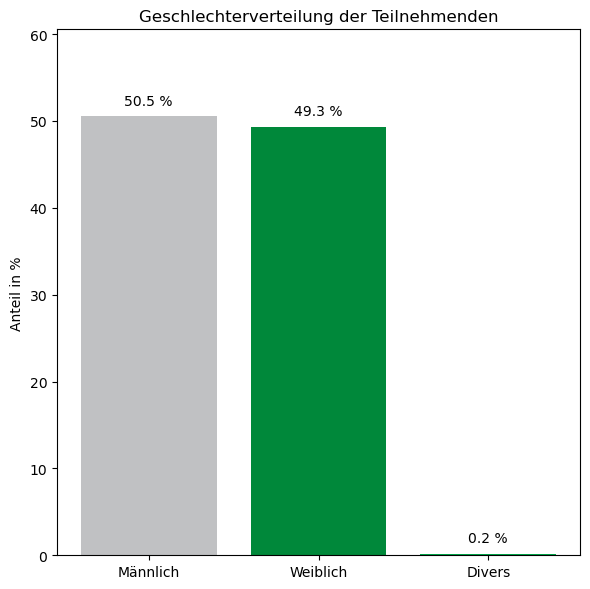

In [36]:
# Deskriptive Statistiken (Häufigkeiten prozentual und absolut) für das Geschlecht
absolute = df_masterprojekt1['PT02'].value_counts().sort_index()
relative = df_masterprojekt1['PT02'].value_counts(normalize=True).sort_index()

haeufigkeitstabelle = pd.DataFrame({
    'Absolute Häufigkeit': absolute,
    'Relative Häufigkeit (%)': (relative * 100).round(2)
})

haeufigkeitstabelle.index = haeufigkeitstabelle.index.map({1: 'Männlich', 2: 'Weiblich', 3: 'Divers'})
print(haeufigkeitstabelle)

# Balkendiagramm statt Kreisdiagramm

labels = haeufigkeitstabelle.index.tolist()
werte = haeufigkeitstabelle['Relative Häufigkeit (%)'].values

x_pos = range(len(labels))

# Farbschema: zwei Grün-Abstufungen + Grau
farben = ['#C0C1C3', '#00883A', '#00A84A']  # Männlich, Weiblich, Divers

plt.figure(figsize=(6, 6))
balken = plt.bar(x_pos, werte, color=farben)

# Prozentwerte über den Balken
for i, v in enumerate(werte):
    plt.text(i, v + 1, f'{v:.1f} %', ha='center', va='bottom', fontsize=10)

plt.xticks(x_pos, labels)
plt.ylabel('Anteil in %')
plt.title('Geschlechterverteilung der Teilnehmenden')
plt.ylim(0, max(werte) + 10)

plt.tight_layout()
plt.show()


### Alter

In [37]:
# Zur Errechnung des Alters in Jahren: 2025 - Geburtstjahr PT01_01
df_masterprojekt1['PT01_01_new'] = 2025 - df_masterprojekt1['PT01_01']

# Kontrolle: erste Werte
df_masterprojekt1['PT01_01_new'].head()

0    36
1    61
2    35
3    47
4    69
Name: PT01_01_new, dtype: int64

In [38]:
# Deskriptive Statistiken (Mittelwert, Median, SD, Min, Max)

df_masterprojekt1['PT01_01_new'].describe()

count    645.000000
mean      44.582946
std       11.688026
min       18.000000
25%       35.000000
50%       44.000000
75%       53.000000
max       69.000000
Name: PT01_01_new, dtype: float64

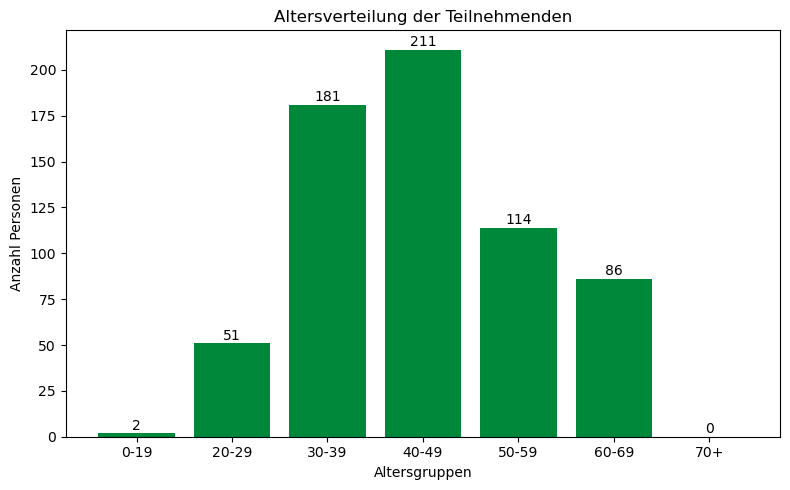

In [39]:
#alternative Visualisierung
# Altersgruppen definieren
bins = [0, 19, 29, 39, 49, 59, 69, 120]
labels = ['0-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']

df_masterprojekt1['Altersgruppe'] = pd.cut(
    df_masterprojekt1['PT01_01_new'], bins=bins, labels=labels, right=True
)

# Anzahl pro Gruppe
altersverteilung = df_masterprojekt1['Altersgruppe'].value_counts().sort_index()

# Balkendiagramm
plt.figure(figsize=(8, 5))
plt.bar(range(len(altersverteilung)), altersverteilung, color='#00883A')

# X-Achsenlabels waagrecht und direkt unter Balken
plt.xticks(range(len(altersverteilung)), labels, rotation=0)

plt.title('Altersverteilung der Teilnehmenden')
plt.xlabel('Altersgruppen')
plt.ylabel('Anzahl Personen')

# Werte auf den Balken
for i, v in enumerate(altersverteilung):
    plt.text(i, v + 0.3, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


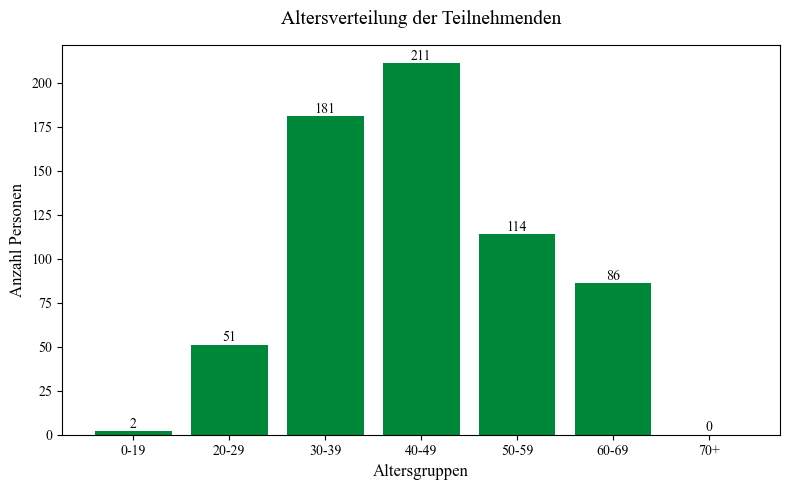

In [40]:
# Schriftart global auf Times New Roman setzen
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

plt.rc('font', family='serif', serif='Times New Roman')

# Altersgruppen definieren
bins = [0, 19, 29, 39, 49, 59, 69, 120]
labels = ['0-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']

df_masterprojekt1['Altersgruppe'] = pd.cut(
    df_masterprojekt1['PT01_01_new'], bins=bins, labels=labels, right=True
)

# Anzahl pro Gruppe
altersverteilung = df_masterprojekt1['Altersgruppe'].value_counts().sort_index()

# Balkendiagramm
plt.figure(figsize=(8, 5))
plt.bar(range(len(altersverteilung)), altersverteilung, color='#00883A')

# X-Achsenlabels waagrecht und direkt unter Balken
plt.xticks(range(len(altersverteilung)), labels, rotation=0, fontfamily='serif')

# Titel und Achsenbeschriftungen mit Schriftartvorgabe
plt.title('Altersverteilung der Teilnehmenden', fontsize=14, pad=15, fontfamily='serif')
plt.xlabel('Altersgruppen', fontsize=12, fontfamily='serif')
plt.ylabel('Anzahl Personen', fontsize=12, fontfamily='serif')

# Werte auf den Balken
for i, v in enumerate(altersverteilung):
    plt.text(i, v + 0.3, str(v), ha='center', va='bottom', fontfamily='serif')

plt.tight_layout()
# Speichern der Grafik für das README (optional)
# plt.savefig('figures/altersverteilung.png', dpi=300)
plt.show()

### Höchster Bildungsabschluss

In [41]:
# ergänzende Tabelle mit Bildungsabschlüssen 

# Labels für Bildungsabschluss 
labels_bildung = {
    1: 'Schüler/-in, besuche eine allgemeinbildende Vollzeitschule',
    2: 'Volks- / Hauptschulabschluss bzw. Polytechnische Oberschule mit Abschluss 8. oder 9. Klasse',
    3: 'mittlere Reife, Realschulabschluss bzw. Polytechnische Oberschule mit Abschluss 10. Klasse',
    4: 'Fachhochschulreife (Abschluss einer Fachoberschule etc.)',
    5: 'Abitur bzw. Erweiterte Oberschule mit Abschluss 12. Klasse (Hochschulreife)',
    6: 'abgeschlossenes Hochschulstudium (Uni/FH)'
}

# Abschluss-Spalte in Textlabels umwandeln
# df_masterprojekt1['PT03'] enthält die numerischen Codes (1–6)
abschluss_series = df_masterprojekt1['PT03'].map(labels_bildung)

# elative Häufigkeiten in % berechnen 
rel_freq = abschluss_series.value_counts(normalize=True, dropna=False) * 100

# HTML-Tabelle im LMU-Grün 
green = "#00883A"

result_df = pd.DataFrame({
    f'<span style="color:{green}"><b>Abschluss</b></span>': rel_freq.index,
    f'<span style="color:{green}"><b>Relative Häufigkeit (%)</b></span>': rel_freq.round(1).values
}).sort_values(
    by=f'<span style="color:{green}"><b>Relative Häufigkeit (%)</b></span>',
    ascending=False
).reset_index(drop=True)

display(HTML(result_df.to_html(escape=False, index=False)))


Abschluss,Relative Häufigkeit (%)
"mittlere Reife, Realschulabschluss bzw. Polytechnische Oberschule mit Abschluss 10. Klasse",50.1
abgeschlossenes Hochschulstudium (Uni/FH),27.0
Abitur bzw. Erweiterte Oberschule mit Abschluss 12. Klasse (Hochschulreife),13.6
Fachhochschulreife (Abschluss einer Fachoberschule etc.),9.3


### Einstellung zur Obergenze

In [42]:
# Deskriptive Statistiken
df_masterprojekt1['PT07'].describe()

count    645.000000
mean       2.541085
std        1.740173
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        6.000000
Name: PT07, dtype: float64

In [43]:
# Einteilung in pro Obergrenze und contra Obergrenze – Werte von 01 bis 03 sind pro Obergrenze, 04 bis 06 contra Obergrenze

map_obergrenze = {
    1: 'pro Obergrenze',
    2: 'pro Obergrenze',
    3: 'pro Obergrenze',
    4: 'contra Obergrenze',
    5: 'contra Obergrenze',
    6: 'contra Obergrenze'
}
df_masterprojekt1['PT07_new'] = df_masterprojekt1['PT07'].map(map_obergrenze)

# Absolute Häufigkeiten
abs_freq = df_masterprojekt1['PT07_new'].value_counts()

# Relative Häufigkeiten in Prozent
rel_freq = df_masterprojekt1['PT07_new'].value_counts(normalize=True) * 100

# Zusammenführen in eine Tabelle
obergrenze_tabelle = pd.DataFrame({
    'Absolute Häufigkeit': abs_freq,
    'Relative Häufigkeit (%)': rel_freq.round(1)
})

print(obergrenze_tabelle)

                   Absolute Häufigkeit  Relative Häufigkeit (%)
PT07_new                                                       
pro Obergrenze                     473                     73.3
contra Obergrenze                  172                     26.7


## Tests rechnen

### Manipulationscheck

In [44]:
# Mittelwertindex bilden: PA02_03, PA02_04 (empathisch)

df_masterprojekt1["index_check_empathisch"] = df_masterprojekt1[["PA02_03", "PA02_04"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_check_empathisch"].describe())
df_masterprojekt1[["PA02_03", "PA02_04", "index_check_empathisch"]].head(10)

count    645.000000
mean       3.653488
std        1.677539
min        1.000000
25%        2.500000
50%        3.500000
75%        5.000000
max        7.000000
Name: index_check_empathisch, dtype: float64


,PA02_03,PA02_04,index_check_empathisch
0,3,3,3.0
1,3,3,3.0
2,3,5,4.0
3,4,4,4.0
4,4,4,4.0
5,2,2,2.0
6,3,2,2.5
7,2,4,3.0
8,4,5,4.5
9,6,4,5.0


In [45]:
# Mittelwertindex bilden: PA02_05, PA02_06 (faktenbasiert)

df_masterprojekt1["index_check_faktenbasiert"] = df_masterprojekt1[["PA02_05", "PA02_06"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_check_faktenbasiert"].describe())
df_masterprojekt1[["PA02_05", "PA02_06", "index_check_faktenbasiert"]].head(10)

count    645.000000
mean       4.129457
std        1.591632
min        1.000000
25%        3.000000
50%        4.000000
75%        5.500000
max        7.000000
Name: index_check_faktenbasiert, dtype: float64


,PA02_05,PA02_06,index_check_faktenbasiert
0,2,6,4.0
1,4,3,3.5
2,3,6,4.5
3,4,5,4.5
4,4,4,4.0
5,4,4,4.0
6,2,3,2.5
7,3,4,3.5
8,5,5,5.0
9,1,4,2.5


In [46]:
# Mittelwertindex bilden: PA02_03, PA02_04, PA02_05, PA02_06 (gemischt)

df_masterprojekt1["index_check_gemischt"] = df_masterprojekt1[["PA02_03", "PA02_04","PA02_05", "PA02_06"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_check_gemischt"].describe())
df_masterprojekt1[["PA02_03", "PA02_04","PA02_05", "PA02_06", "index_check_gemischt"]].head(10)

count    645.000000
mean       3.891473
std        1.431757
min        1.000000
25%        3.000000
50%        4.000000
75%        4.750000
max        7.000000
Name: index_check_gemischt, dtype: float64


,PA02_03,PA02_04,PA02_05,PA02_06,index_check_gemischt
0,3,3,2,6,3.50
1,3,3,4,3,3.25
2,3,5,3,6,4.25
3,4,4,4,5,4.25
4,4,4,4,4,4.00
5,2,2,4,4,3.00
6,3,2,2,3,2.50
7,2,4,3,4,3.25
8,4,5,5,5,4.75
9,6,4,1,4,3.75


In [47]:
# Überprüfen mit dem Kommunikationsstil

print(df_masterprojekt1["index_check_gemischt"].describe())
df_masterprojekt1[["IN02_new","index_check_empathisch", "index_check_faktenbasiert", "index_check_gemischt"]].head(10)

count    645.000000
mean       3.891473
std        1.431757
min        1.000000
25%        3.000000
50%        4.000000
75%        4.750000
max        7.000000
Name: index_check_gemischt, dtype: float64


,IN02_new,index_check_empathisch,index_check_faktenbasiert,index_check_gemischt
0,empathisch,3.0,4.0,3.50
1,empathisch,3.0,3.5,3.25
2,empathisch,4.0,4.5,4.25
3,empathisch,4.0,4.5,4.25
4,faktenbasiert,4.0,4.0,4.00
5,empathisch,2.0,4.0,3.00
6,empathisch,2.5,2.5,2.50
7,gemischt,3.0,3.5,3.25
8,faktenbasiert,4.5,5.0,4.75
9,gemischt,5.0,2.5,3.75


### Interaktionseffekt

In [48]:
def run_anova(df_manipulationscheck, av, title): # Definieren einer neuen Funktion, die jeweils drei Anovas durchführt; var steht für unsere abhängige Variable
    print(f"\n===== {title} =====\n") # dient lediglich der Übersichtlichkeit des Outputs; title = Überschrift für den Block

    df_manipulationscheck = df_manipulationscheck[[av, 'IN02_new']].dropna().copy() # Arbeitsdataframe, um die relevanten Spalten auszuwählen (av = Index)
    df_manipulationscheck['IN02_new'] = df_manipulationscheck['IN02_new'].astype('category') # Gruppierungsvariable als kategorial festlegen

    print("Deskriptive Werte:")
    print(df_manipulationscheck.groupby('IN02_new')[av].agg(['count','mean','std']), "\n") # gibt uns jeweils Anzahl, Mittelwert und Standardabweichung je Gruppe aus

    model = ols(f'{av} ~ C(IN02_new)', data=df_manipulationscheck).fit() # lineares Modell 8AV wird durch die kategoriale Variable IN02_new vorhergesagt)
    print("ANOVA:")
    print(anova_lm(model, typ=2), "\n") # Durchführen der Varianzanalyse

    groups = df_manipulationscheck['IN02_new'].cat.categories # Gruppen und Paarvergleiche (Post-hoc)
    pairs = list(itertools.combinations(groups, 2)) # Erzeugen aller 2er-Kombinationen (3 Paarvergleiche) - benutze bereits importiertes itertools

    results_manipulationscheck = []
    for g1, g2 in pairs: # Schleife über alle Gruppenpaare
        x = df_manipulationscheck.loc[df_manipulationscheck['IN02_new'] == g1, av]
        y = df_manipulationscheck.loc[df_manipulationscheck['IN02_new'] == g2, av]
        t, p = ttest_ind(x, y, equal_var=False)
        results_manipulationscheck.append([g1, g2, x.mean(), y.mean(), p]) # Speichern in einer Liste: Gruppenname, Mittelwerte, p-Wert

    results_manipulationscheck = pd.DataFrame(results_manipulationscheck, columns=['g1','g2','m1','m2','p_unc'])
    results_manipulationscheck['p_bonf'] = multipletests(results_manipulationscheck['p_unc'], method='bonferroni')[1]

    print("Post-hoc (Bonferroni):")
    print(results_manipulationscheck, "\n")


run_anova(df_masterprojekt1, "index_check_empathisch", "Block 1: Empathischer Manipulationscheck")
run_anova(df_masterprojekt1, "index_check_faktenbasiert", "Block 2: Faktenbasierter Manipulationscheck")
run_anova(df_masterprojekt1, "index_check_gemischt", "Block 3: Gemischter Manipulationscheck")


===== Block 1: Empathischer Manipulationscheck =====

Deskriptive Werte:
               count      mean       std
IN02_new                                
empathisch       222  3.759009  1.694224
faktenbasiert    215  3.416279  1.610412
gemischt         208  3.786058  1.709210 

ANOVA:
                  sum_sq     df         F    PR(>F)
C(IN02_new)    18.225079    2.0  3.260864  0.038991
Residual     1794.079573  642.0       NaN       NaN 

Post-hoc (Bonferroni):
              g1             g2        m1        m2     p_unc    p_bonf
0     empathisch  faktenbasiert  3.759009  3.416279  0.030704  0.092112
1     empathisch       gemischt  3.759009  3.786058  0.869266  1.000000
2  faktenbasiert       gemischt  3.416279  3.786058  0.022605  0.067815 


===== Block 2: Faktenbasierter Manipulationscheck =====

Deskriptive Werte:
               count      mean       std
IN02_new                                
empathisch       222  3.713964  1.571935
faktenbasiert    215  4.434884  1.533258


In [49]:
# Interaktionseffekt zwischen dem Manipulationscheck ("index_check_empathisch", "index_check_faktenbasiert" und "index_check_gemischt") und der Meinungsextremität (Variable noch erstellen)

# Gruppen zusammenfassen (Meinungsextremität)

# 1+2+3=moderat, 3+4+5=extrem
in02_num2 = pd.to_numeric(df_masterprojekt1['IN02'], errors='coerce')
_map = {1: 'moderat', 2: 'moderat',
        3: 'moderat', 4: 'extrem',
        5: 'extrem', 6: 'extrem'}
df_masterprojekt1['IN02_extremität'] = in02_num.map(_map)

df_masterprojekt1[["IN02","IN02_extremität"]].head(10)

,IN02,IN02_extremität
0,3,moderat
1,6,extrem
2,3,moderat
3,3,moderat
4,4,extrem
5,6,extrem
6,6,extrem
7,5,extrem
8,1,moderat
9,2,moderat


                                     sum_sq     df          F        PR(>F)
C(IN02_new)                       17.397771    2.0   3.507554  3.054848e-02
C(IN02_extremität)               184.289209    1.0  74.308868  5.245881e-17
C(IN02_new):C(IN02_extremität)    25.042715    2.0   5.048846  6.675107e-03
Residual                        1584.747649  639.0        NaN           NaN


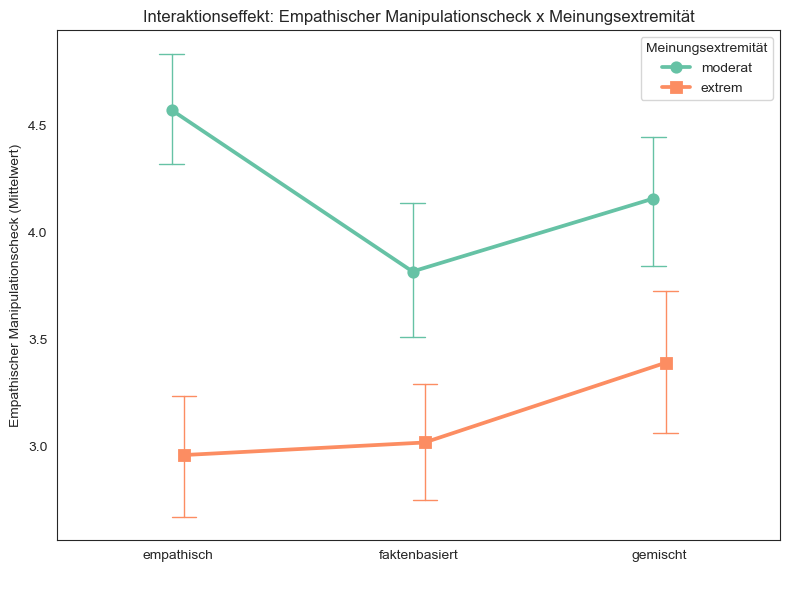

                                     sum_sq     df          F        PR(>F)
C(IN02_new)                       60.765762    2.0  13.261459  2.274786e-06
C(IN02_extremität)               103.888203    1.0  45.344915  3.685245e-11
C(IN02_new):C(IN02_extremität)     1.784757    2.0   0.389504  6.775538e-01
Residual                        1463.991306  639.0        NaN           NaN


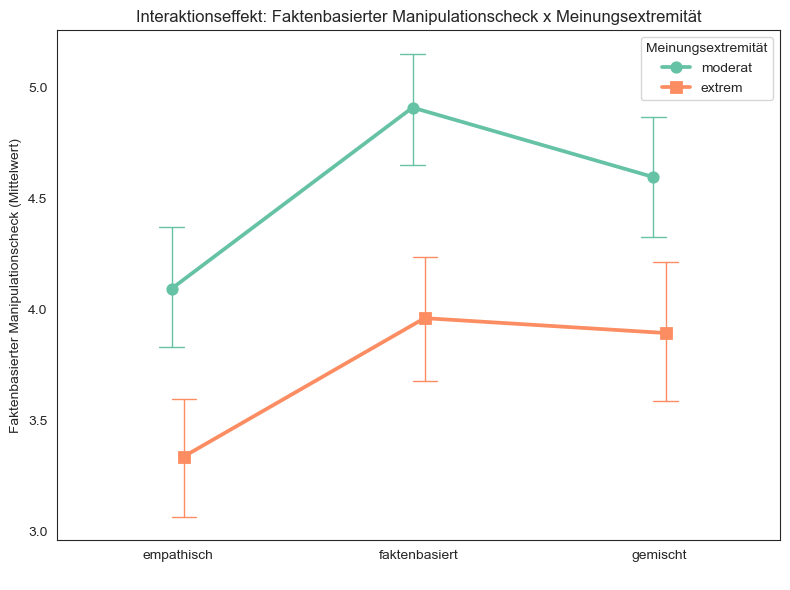

                                     sum_sq     df          F        PR(>F)
C(IN02_new)                        8.155849    2.0   2.238497  1.074541e-01
C(IN02_extremität)               141.227940    1.0  77.524323  1.223883e-17
C(IN02_new):C(IN02_extremität)     5.736664    2.0   1.574515  2.079104e-01
Residual                        1164.081802  639.0        NaN           NaN


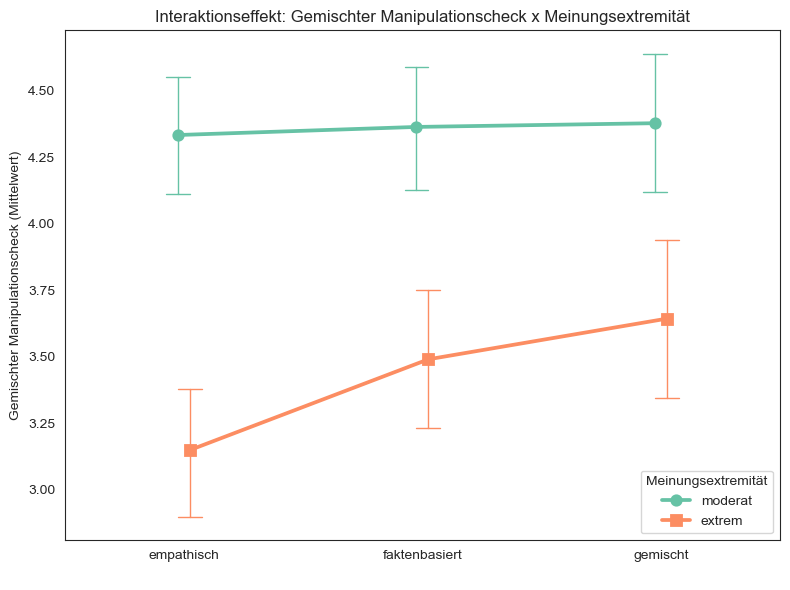

In [50]:
# Interaktionseffekt: empathischer Manipulationscheck x Meinungsextremität
model_interaktion_empathisch = ols('index_check_empathisch ~ C(IN02_new) * C(IN02_extremität)', data=df_masterprojekt1).fit()
print(anova_lm(model_interaktion_empathisch, typ=2))

# Visualisierung des Interaktionseffekts (empatisch)

sns.set_style("white")
plt.figure(figsize=(8, 6))
sns.pointplot(
    data=df_masterprojekt1,
    x='IN02_new',
    y='index_check_empathisch',
    hue='IN02_extremität',
    dodge=True,
    markers=['o', 's'],
    capsize=.1,
    errwidth=1,
    palette='Set2'
)
plt.title('Interaktionseffekt: Empathischer Manipulationscheck x Meinungsextremität')
plt.xlabel(' ')
plt.ylabel('Empathischer Manipulationscheck (Mittelwert)')
plt.legend(title='Meinungsextremität')
plt.tight_layout()
plt.show()

# Interaktionseffekt: faktenbasierter Manipulationscheck x Meinungsextremität
model_interaktion_faktenbasiert = ols('index_check_faktenbasiert ~ C(IN02_new) * C(IN02_extremität)', data=df_masterprojekt1).fit()
print(anova_lm(model_interaktion_faktenbasiert, typ=2))

# Visualisierung des Interaktionseffekts (faktenbasiert)

plt.figure(figsize=(8, 6))
sns.pointplot(
    data=df_masterprojekt1,
    x='IN02_new',
    y='index_check_faktenbasiert',
    hue='IN02_extremität',
    dodge=True,
    markers=['o', 's'],
    capsize=.1,
    errwidth=1,
    palette='Set2'
)
plt.title('Interaktionseffekt: Faktenbasierter Manipulationscheck x Meinungsextremität')
plt.xlabel(' ')
plt.ylabel('Faktenbasierter Manipulationscheck (Mittelwert)')
plt.legend(title='Meinungsextremität')
plt.tight_layout()
plt.show()

# Interaktionseffekt: gemischter Manipulationscheck x Meinungsextremität
model_interaktion_gemischt = ols('index_check_gemischt ~ C(IN02_new) * C(IN02_extremität)', data=df_masterprojekt1).fit()
print(anova_lm(model_interaktion_gemischt, typ=2))

# Visualisierung des Interaktionseffekts (gemischt)
plt.figure(figsize=(8, 6))
sns.pointplot(
    data=df_masterprojekt1,
    x='IN02_new',
    y='index_check_gemischt',
    hue='IN02_extremität',
    dodge=True,
    markers=['o', 's'],
    capsize=.1,
    errwidth=1,
    palette='Set2'
)
plt.title('Interaktionseffekt: Gemischter Manipulationscheck x Meinungsextremität')
plt.ylabel('Gemischter Manipulationscheck (Mittelwert)')
plt.xlabel(' ')
plt.legend(title='Meinungsextremität')
plt.tight_layout()
plt.show()

In [51]:
# Simple Effect testen für den empathischen KS

df_emp = df_masterprojekt1[df_masterprojekt1["IN02_new"] == "empathisch"]

mod = df_emp[df_emp["IN02_extremität"] == "moderat"]["index_check_empathisch"]
ext = df_emp[df_emp["IN02_extremität"] == "extrem"]["index_check_empathisch"]

t_stat, p_val = ttest_ind(mod, ext, equal_var=False)

print(f"Simple Effect (empathisch): t = {t_stat:.2f}, p = {p_val:.3e}")


Simple Effect (empathisch): t = 8.06, p = 4.997e-14


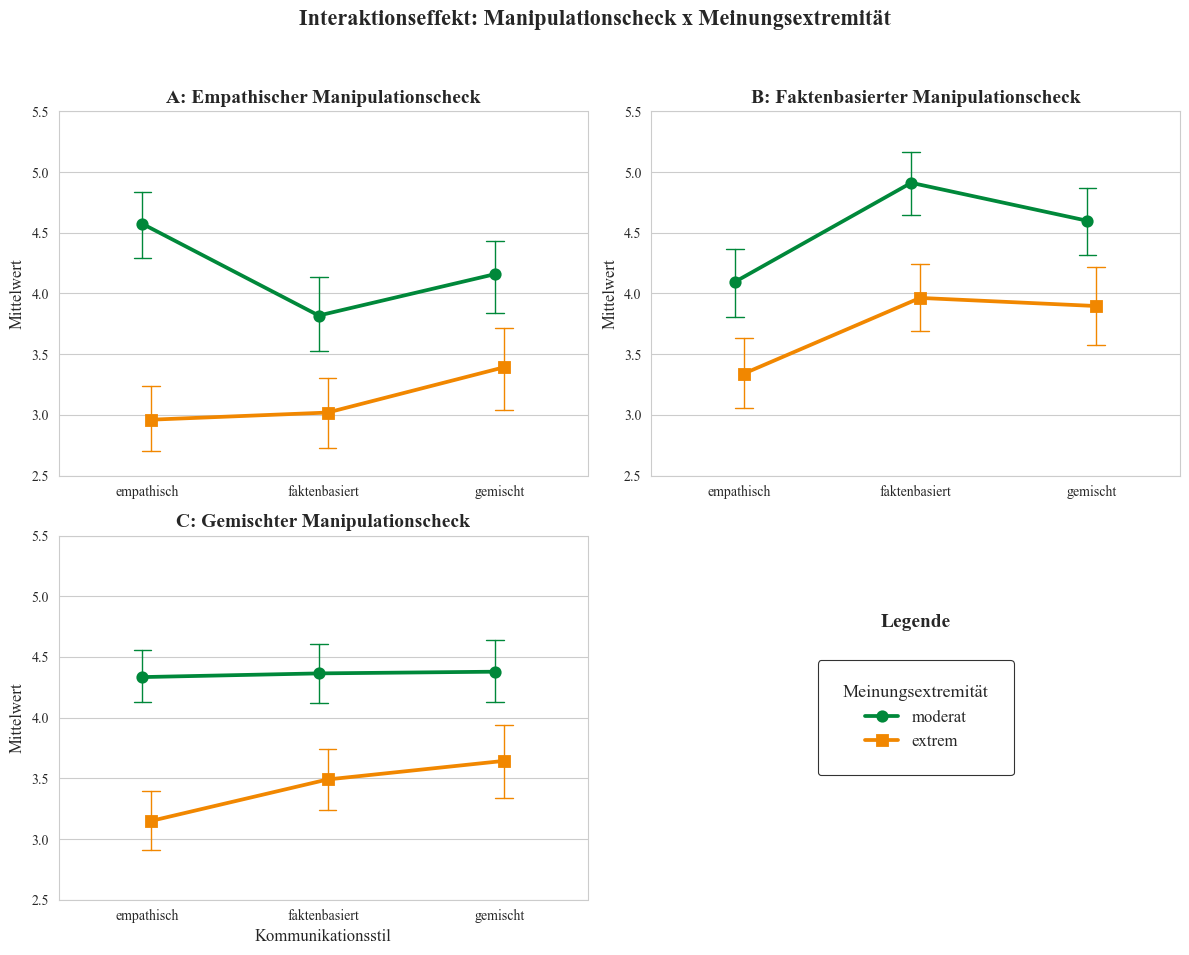

In [52]:
# Schriftart auf Times New Roman einstellen
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# Definition der spezifischen Farben
farb_mapping = {'moderat': '#00883A', 'extrem': '#F18700'}

# Grund-Einstellungen für das Layout
sns.set_style("whitegrid", {"font.family": "serif", "font.serif": ["Times New Roman"]})
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# TITEL
fig.suptitle('Interaktionseffekt: Manipulationscheck x Meinungsextremität', 
             fontsize=16, fontweight='bold', y=0.98)

# Einheitliche y-Achse für die Vergleichbarkeit
y_min, y_max = 2.5, 5.5 

# Liste der AVs und Titel
av_list = [
    ('index_check_empathisch', 'A: Empathischer Manipulationscheck', axes[0, 0]),
    ('index_check_faktenbasiert', 'B: Faktenbasierter Manipulationscheck', axes[0, 1]),
    ('index_check_gemischt', 'C: Gemischter Manipulationscheck', axes[1, 0])
]

# Plots in der Schleife erstellen
for column, title, ax in av_list:
    sns.pointplot(
        data=df_masterprojekt1,
        x='IN02_new',
        y=column,
        hue='IN02_extremität',
        dodge=True,
        markers=['o', 's'],
        capsize=.1,
        err_kws={'linewidth': 1},
        palette=farb_mapping,  # Deine neuen Farben
        ax=ax
    )
    ax.set_title(title, fontweight='semibold', fontsize=14)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel('Mittelwert', fontsize=12)
    
    # x-Achse nur unten beschriften
    if ax == axes[1, 0]:
        ax.set_xlabel('Kommunikationsstil', fontsize=12)
    else:
        ax.set_xlabel('')
        
    ax.get_legend().remove()

# Das 4. Feld (unten rechts) als professionelle Infobox
ax_leg = axes[1, 1]
ax_leg.axis('off')

# Legende extrahieren und im leeren Feld stylen
handles, labels = axes[0, 0].get_legend_handles_labels()
leg = ax_leg.legend(
    handles, 
    labels, 
    title='Meinungsextremität', 
    loc='center', 
    fontsize=12, 
    title_fontsize=13,
    frameon=True, 
    edgecolor='black',
    borderpad=1.5
)
leg.get_frame().set_linewidth(0.8)

# Zusätzliche Info-Texte 
ax_leg.text(0.5, 0.75, 'Legende', 
            transform=ax_leg.transAxes, ha='center', 
            fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])


plt.show()

### Hypothese 1

In [53]:
# Voraussetzungen prüfen

#Levene-Test auf Varianzhomogenität

# Daten 
df_anovaH1 = df_masterprojekt1[['affektive_polarisierung', 'IN02_new']].dropna()
df_anovaH1['IN02_new'] = df_anovaH1['IN02_new'].astype('category')

# Gruppenübersicht
print(df_anovaH1.groupby('IN02_new')['affektive_polarisierung'].agg(['count','mean','std']))

# Test auf Varianzhomogenität (Levene)
gruppenwerte = [
    df_anovaH1.loc[df_anovaH1['IN02_new'] == g, 'affektive_polarisierung']
    for g in df_anovaH1['IN02_new'].cat.categories
]

stat, p = levene(*gruppenwerte, center='mean')

k = len(gruppenwerte)        # Anzahl Gruppen
N = len(df_anovaH1)          # Gesamtstichprobe
df1 = k - 1
df2 = N - k

levene_table = pd.DataFrame({
    'Levene-Statistik': [stat],
    'df1': [df1],
    'df2': [df2],
    'p-Wert': [p]
}).round(4)

print("\nTest auf Varianzhomogenität (Levene):")
print(levene_table)


               count      mean       std
IN02_new                                
empathisch       222  3.995495  3.311160
faktenbasiert    215  4.237209  3.335523
gemischt         208  4.028846  3.526180

Test auf Varianzhomogenität (Levene):
   Levene-Statistik  df1  df2  p-Wert
0            1.2904    2  642  0.2759


In [54]:
# Hypothese 1a: Ein Gespräch mit einem LLM, das einen faktenbasierten KS verwendet, führt bei Befragten zu einer stärkeren affektiven Polarisierung als ein empathischer sowie ein gemischter KS.

# Hypothese 1b: Ein gemischter KS führt zu einer geringeren affektiven Polarisierung als ein empathischer sowie faktenbasierter KS.

# Daten 
df_anovaH1 = df_masterprojekt1[['affektive_polarisierung', 'IN02_new']].dropna() # Dataframe erstellen mit den beiden Variablen (AP & KS)
df_anovaH1['IN02_new'] = df_anovaH1['IN02_new'].astype('category') #Umwandlung der Variable IN02_new in einen kategorialen Datentyp

# Gruppenübersicht - zeigt die AP deskriptiv für jeden Kommunikationsstil
print(df_anovaH1.groupby('IN02_new')['affektive_polarisierung'].agg(['count','mean','std']))

# ANOVA (Haupteffekt)
modelH1 = ols('affektive_polarisierung ~ C(IN02_new)', data=df_anovaH1).fit() # erstellt ein lineares Modell (ols) mit der Av affektive_polarisierung und der UV IN02_new
print(anova_lm(modelH1, typ=2)) # Durchführen einer Varianzanalyse 

# Post-hoc (Welch) + Bonferroni
groupsH1 = df_anovaH1['IN02_new'].cat.categories.tolist() # holt alle Kategorien (empathisch, faktenbasiert, gemischt) als Liste
pairs = list(it.combinations(groupsH1, 2)) # Erstellen aller möglichen 2er-Kombinationen dieser Gruppen (paarweiser Vergleich)

results = []
for g1, g2 in pairs:
    x = df_anovaH1.loc[df_anovaH1['IN02_new'] == g1, 'affektive_polarisierung']
    y = df_anovaH1.loc[df_anovaH1['IN02_new'] == g2, 'affektive_polarisierung']
    t, p = ttest_ind(x, y, equal_var=False, nan_policy='omit')
    results.append({'g1': g1, 'g2': g2, 'n1': x.size, 'n2': y.size, # Gruppennamen g1, g2; Stichprobengröße n1, n2
                    'm1': x.mean(), 'm2': y.mean(), 't': t, 'p_unc': p}) # Mittelwerte m1, m2; t-Wert: t; unkorrekten p-Wert: p_unc

p_adj = multipletests([r['p_unc'] for r in results], method='bonferroni') # holt alle unkorrekten p-Werte und korrigiert sie nac Bonferroni
for r, p_b, sig in zip(results, p_adj[1], p_adj[0]):# Hinzufügen des korrigierten Ergebnisses
    r['p_bonf'] = p_b # Bonferroni-korrigierten p-Wert
    r['sig_bonf'] = sig #True/False, ob signifikant nach Bonferroni 


posthoc_df = pd.DataFrame(results).sort_values('p_bonf') # Ergebnistabelle 
print(posthoc_df[['g1','g2','n1','n2','m1','m2','t','p_unc','p_bonf','sig_bonf']].round(4)) 

               count      mean       std
IN02_new                                
empathisch       222  3.995495  3.311160
faktenbasiert    215  4.237209  3.335523
gemischt         208  4.028846  3.526180
                  sum_sq     df         F   PR(>F)
C(IN02_new)     7.413240    2.0  0.322545  0.72442
Residual     7377.724744  642.0       NaN      NaN
              g1             g2   n1   n2      m1      m2       t   p_unc  \
0     empathisch  faktenbasiert  222  215  3.9955  4.2372 -0.7601  0.4476   
1     empathisch       gemischt  222  208  3.9955  4.0288 -0.1009  0.9196   
2  faktenbasiert       gemischt  215  208  4.2372  4.0288  0.6239  0.5330   

   p_bonf  sig_bonf  
0     1.0     False  
1     1.0     False  
2     1.0     False  


 - Allgemein fällt auf, dass die Mittelwerte für die drei Bedingungen recht nah beieinander liegen -> keine inhaltlich bedeutsamen Unterschiede erkennbar
 
 - deskriptiv: Tendenziell etwas höhere affektive Polarisierung bei faktenbasiert und gemischt als bei empathisch, aber Streuung sehr hoch, besonders bei gemischt. (siehe mean & std)
 
 - F(2,642) = 0.32, p = 0.724 -> kein signifikanter Haupteffekt des Kommunikationsstils auf die affektive Polarisierung
 
 - Post-hoc-Vergleiche: keiner der drei Vergleiche ist signifikant (siehe p-Wert = 1.0 nach Bonferroni-Korrektur: p_bonf & 3mal False)

 - Interpretation: Der Kommunikationsstil hat keinen Einfluss auf die affektive Polarisierung. 

### Hypothese 2

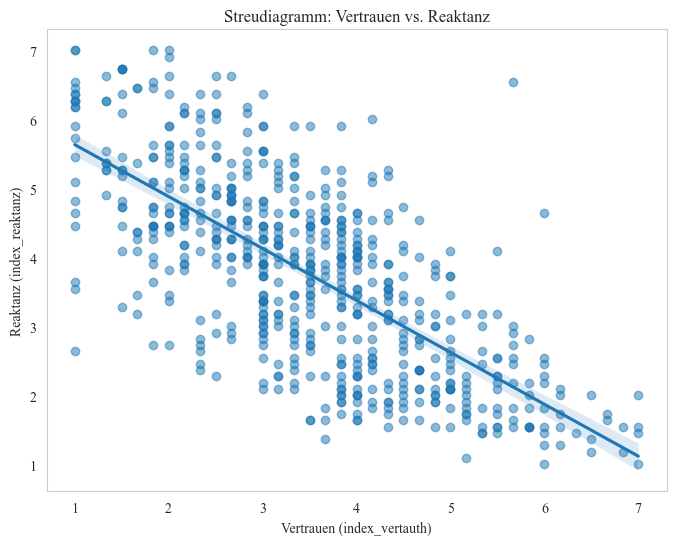

In [55]:
# Voraussetzungen für bivariate Korrelation prüfen (bivariate Normalverteilung) von Vertrauen (index_vertauth) und Reaktanz (index_reaktanz)
# Streudiagramm mit Regressionslinie
plt.figure(figsize=(8, 6))
sns.regplot(x='index_vertauth', y='index_reaktanz', data=df_masterprojekt1, scatter_kws={'alpha':0.5})
plt.title('Streudiagramm: Vertrauen vs. Reaktanz')
plt.xlabel('Vertrauen (index_vertauth)')
plt.ylabel('Reaktanz (index_reaktanz)')
plt.grid()
plt.show()

In [56]:
# Hypothese H2:Je höher das Vertrauen in den Chatbot ausfällt, desto geringer ist die Reaktanz gegenüber dem Chatbot.
# Bivariate Korrelation - UV: Mittelwertindex Vertrauen + wahrgenommene Authentizität, AV: Mittelwertindex Reaktanz

colsH2 = ['index_vertauth', 'index_reaktanz'] # definiert die zwei Spaltennamen, die für die Korrelation verwendet werden
df_corr = df_masterprojekt1[colsH2].apply(pd.to_numeric, errors='coerce').dropna() # Zeilen mit fehlende Werten entfernen

x, y = df_corr['index_vertauth'], df_corr['index_reaktanz'] # Kurzvariablen anlegen für Vertrauen (x) und Reaktanz (y)

print(f"n = {len(df_corr)}") # Stichprobengröße
print(df_corr.describe().loc[['mean','std']].round(3)) # Deskriptive Statistik ausgeben (Mittelwert, Standardabweichung)

# Korrelationen
r_p, p_p = pearsonr(x, y) # Pearson-Korrelation, inkl. p-Wert
r_s, p_s = spearmanr(x, y) # Spearman-Korrelation, inkl.p-Wert

# kompakte Tabelle ausgeben
out = pd.DataFrame({
    'Test': ['Pearson (r)', 'Spearman (ρ)'],
    'Koeffizient': [r_p, r_s],
    'p-Wert': [p_p, p_s],
    'Richtung (H2 erwartet negativ)': ['negativ' if r_p < 0 else 'positiv',
                                       'negativ' if r_s < 0 else 'positiv']
}).round(4)
print("\nErgebnisse:\n", out.to_string(index=False))


n = 645
      index_vertauth  index_reaktanz
mean           3.482           3.766
std            1.301           1.383

Ergebnisse:
         Test  Koeffizient  p-Wert Richtung (H2 erwartet negativ)
 Pearson (r)      -0.7083     0.0                        negativ
Spearman (ρ)      -0.7032     0.0                        negativ


- deskriptiv: beide Variablen sind ungefähr im mittleren Bereich angesiedelt
- relativ große Streuungen 
- Pearson-Korrelation: sehr starker negativer Zusammenhang -> Je höher das Vertrauen, desto geringer die Reaktanz + hochsignifikant, denn p<.001 
- Die H2 kann angenommen werden, d.h. je höher das Vertrauen in den Chatbot, desto geringer die Reaktanz.

In [57]:
# bei Bedarf: detailliertere Analyse (multivariate Regression)
# AV 1: wahrgenommene Freiheitseinschränkung; AV 2: affektive Reaktanz-Dimension; AV 3: kognitive Reaktanz-Dimension

# Daten vorbereiten
cols_regression = ['index_vertauth', 'index_affreaktanz', 'index_kogreaktanz', 'index_freiheitseinschraenkung'] # Liste definieren mit unserer UV und den drei AVs
df_regressionH2 = df_masterprojekt1[cols_regression].apply(pd.to_numeric, errors='coerce').dropna() # relevanten Spalten auswählen & alle Werte in Zahlen umwandeln

X = df_regressionH2['index_vertauth'] # unabhängige Variable - unseren Prädiktor Vertrauen+ wahrgenommene Authentizität erstellen
X = sm.add_constant(X)  # Konstante hinzufügen (Achsenabschnitt für die Regressionsgerade)

# Liste der AVs
avs = ['index_affreaktanz', 'index_kogreaktanz', 'index_freiheitseinschraenkung']
av_namen = ['Affektive Reaktanz', 'Kognitive Reaktanz', 'Wahrgenommene Freiheitseinschränkung'] # lesbar für die ausgabe

print(f"Stichprobengröße: n = {len(df_regressionH2)}\n")
print("="*80) # Trennlinie (bessere Lesbarkeit)

# Schleife über alle drei Reaktanz-Dimensionen
for av, name in zip(avs, av_namen): # paralleles Durchlaufen der drei AVs
    print(f"\n### REGRESSION: {name} ###\n") # Überschrift für jede Regression
    
    y = df_regressionH2[av] # holt die aktuelle abhängige Variable aus dem DataFrame
    
    # Regression rechnen
    model = sm.OLS(y, X).fit() # OLS = Ordinary Least Squares (klassische lineare Regression)
    
    # Kompakte Ergebnistabelle
    resultsH2 = pd.DataFrame({
        'Koeffizient': model.params, # Regressionskoeffizienten (b1 = Steigung für Vertrauen)
        'SE': model.bse, # Standardfehler der Koeffizienten
        'β (standardisiert)': [0, stats.pearsonr(df_regressionH2['index_vertauth'], y)[0]],
        't-Wert': model.tvalues,
        'p-Wert': model.pvalues
    }).round(4)
    
    print(resultsH2)
    print(f"\nR² = {model.rsquared:.4f}") # Anteil der erklärten Variant
    print(f"Adj. R² = {model.rsquared_adj:.4f}") # korrigiertes R-Quadrat
    print(f"F-Statistik = {model.fvalue:.4f}, p = {model.f_pvalue:.4f}") # testen, ob das Gesamtmodell signifikant ist
    print(f"\nInterpretation: Pro Einheit mehr Vertrauen sinkt/steigt {name} um {model.params['index_vertauth']:.4f} Einheiten.")
    print("="*80)


Stichprobengröße: n = 645


### REGRESSION: Affektive Reaktanz ###

                Koeffizient      SE  β (standardisiert)   t-Wert  p-Wert
const                5.8603  0.1740              0.0000  33.6846     0.0
index_vertauth      -0.7417  0.0468             -0.5299 -15.8448     0.0

R² = 0.2808
Adj. R² = 0.2797
F-Statistik = 251.0576, p = 0.0000

Interpretation: Pro Einheit mehr Vertrauen sinkt/steigt Affektive Reaktanz um -0.7417 Einheiten.

### REGRESSION: Kognitive Reaktanz ###

                Koeffizient      SE  β (standardisiert)   t-Wert  p-Wert
const                7.6641  0.0961              0.0000  79.7402     0.0
index_vertauth      -0.7532  0.0259             -0.7542 -29.1233     0.0

R² = 0.5688
Adj. R² = 0.5681
F-Statistik = 848.1642, p = 0.0000

Interpretation: Pro Einheit mehr Vertrauen sinkt/steigt Kognitive Reaktanz um -0.7532 Einheiten.

### REGRESSION: Wahrgenommene Freiheitseinschränkung ###

                Koeffizient      SE  β (standardisiert)   t-Wert  p-

- Interpretation pro AV
    - Affektive Reaktanz: b = -0.742 -> Je höher das Vertrauen, desto geringer die affektive Reaktanz; beta = -0.53 (mittlerer bis starker Effekt); R^2 = 0.281 (Vertrauen erklärt 28% der Varianz) -> deutlicher negativer Zusammenhang
    - Kognitive Reaktanz: b = - 0.743 -> Je höher das Vertrauen, desto geringer die kognitive Reaktanz; beta = 0.754 (sehr starker negativer Effekt); R^2 = 0.569 (Vertrauen erklärt 57% der Varianz) -> stärkster Zusammenhang 
    - Wahrgenommene Freiheitseinschränkung: b = -0.764 -> Je höher das Vertrauen, desto geringer die wahrgenommene Freiheitseinschränkung; beta = -0.594(starker Effekt); R^2 = 0.353 (Vertrauen erklärt 35% der Varianz) -> klarer negativer Zusammenhang (stärker als bei affektiver Reaktanz)

n = 645

--- Deskriptive Statistiken: Vertrauen pro Kommunikationsstil ---
               count   mean    std
IN02_new                          
empathisch       222  3.478  1.302
faktenbasiert    215  3.466  1.249
gemischt         208  3.502  1.357

--- ANOVA Ergebnisse ---
                df       sum_sq   mean_sq         F   PR(>F)
C(IN02_new)    2.0     0.138796  0.069398  0.040866  0.95996
Residual     642.0  1090.227440  1.698174       NaN      NaN

--- Post-hoc Vergleich (Tukey-HSD) ---
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2    meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------
   empathisch faktenbasiert  -0.0123 0.9946 -0.3053 0.2806  False
   empathisch      gemischt   0.0234 0.9811  -0.272 0.3188  False
faktenbasiert      gemischt   0.0357 0.9572  -0.262 0.3334  False
-----------------------------------------------------------------


<Figure size 1000x600 with 0 Axes>

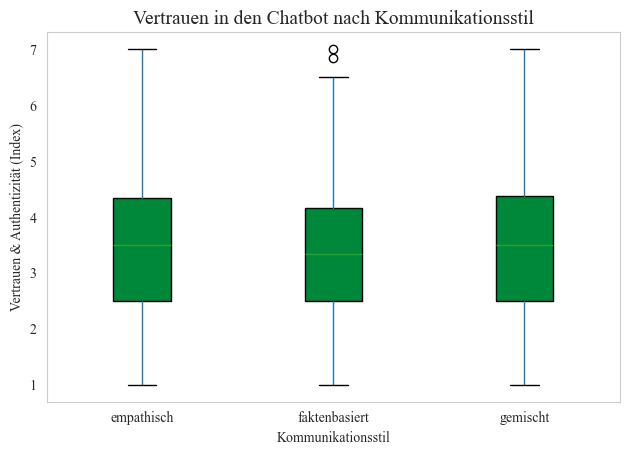

In [58]:
# explorativer Teil: Unterscheidet sich das Vertrauen und die wahrgenommene Authentizität je nach Kommunikationsstil?

# 1. Daten vorbereiten & bereinigen
cols_explorativ = ['IN02_new', 'index_vertauth']
df_exp = df_masterprojekt1[cols_explorativ].dropna()

print(f"n = {len(df_exp)}")

# 2. Deskriptive Statistiken nach Gruppe
# Zeigt uns: Welcher KS hat den höchsten Vertrauens-Mittelwert?
stats_summary = df_exp.groupby('IN02_new')['index_vertauth'].agg(['count', 'mean', 'std']).round(3)
print("\n--- Deskriptive Statistiken: Vertrauen pro Kommunikationsstil ---")
print(stats_summary)

# 3. Einfaktorielle ANOVA
# Testet: Gibt es überhaupt einen signifikanten Unterschied zwischen den Gruppen?
model = ols('index_vertauth ~ C(IN02_new)', data=df_exp).fit()
anova_results = anova_lm(model)
print("\n--- ANOVA Ergebnisse ---")
print(anova_results)

# 4. Post-hoc Test (Tukey HSD)
# Wenn ANOVA signifikant: Wer unterscheidet sich von wem?
tukey = pairwise_tukeyhsd(endog=df_exp['index_vertauth'], 
                          groups=df_exp['IN02_new'], 
                          alpha=0.05)
print("\n--- Post-hoc Vergleich (Tukey-HSD) ---")
print(tukey)

# 5. Visualisierung (Boxplot)
plt.figure(figsize=(10, 6))
# Wir nutzen die LMU-Farben-Logik
lmu_green = "#00883A"
df_exp.boxplot(column='index_vertauth', by='IN02_new', grid=False, 
               patch_artist=True, boxprops=dict(facecolor=lmu_green, color='black'))

plt.title('Vertrauen in den Chatbot nach Kommunikationsstil', fontfamily='serif', fontsize=14)
plt.suptitle('') # Entfernt den automatischen Panda-Titel
plt.xlabel('Kommunikationsstil', fontfamily='serif')
plt.ylabel('Vertrauen & Authentizität (Index)', fontfamily='serif')
plt.xticks(fontfamily='serif')
plt.yticks(fontfamily='serif')
plt.tight_layout()
plt.show()

### Hypothese 3

In [59]:
'IN02_new' in df_masterprojekt1.columns

True

In [60]:
if 'IN02_new' in df_masterprojekt1.columns:
    # 1. Dummys separat generieren (auf die Spalte direkt angewendet)
    dummies = pd.get_dummies(df_masterprojekt1['IN02_new'], prefix='IN02_new', drop_first=True)
    
    # 2. Die Dummys an den ursprünglichen DataFrame anhängen
    df_masterprojekt1 = pd.concat([df_masterprojekt1, dummies], axis=1)
else:
    print("Spalte IN02_new nicht gefunden oder Dummys bereits vorhanden.")

print(df_masterprojekt1.columns)

Index(['CASE', 'SERIAL', 'REF', 'QUESTNNR', 'MODE', 'STARTED', 'CH01_01',
       'ID01_RV1', 'IN02_CP', 'IN02',
       ...
       'index_reaktanz', 'PT01_01_new', 'Altersgruppe', 'PT07_new',
       'index_check_empathisch', 'index_check_faktenbasiert',
       'index_check_gemischt', 'IN02_extremität', 'IN02_new_faktenbasiert',
       'IN02_new_gemischt'],
      dtype='object', length=243)


In [61]:
# Werte abgleichen (Dummyvariablen)
df_masterprojekt1[['IN02', 'IN02_new', 'faktenbasiert_dich', 'gemischt_dich', 'empathisch_dich', 'IN02_new_faktenbasiert', 'IN02_new_gemischt']].head(10)

,IN02,IN02_new,faktenbasiert_dich,gemischt_dich,empathisch_dich,IN02_new_faktenbasiert,IN02_new_gemischt
0,3,empathisch,0,0,1,False,False
1,6,empathisch,0,0,1,False,False
2,3,empathisch,0,0,1,False,False
3,3,empathisch,0,0,1,False,False
4,4,faktenbasiert,1,0,0,True,False
5,6,empathisch,0,0,1,False,False
6,6,empathisch,0,0,1,False,False
7,5,gemischt,0,1,0,False,True
8,1,faktenbasiert,1,0,0,True,False
9,2,gemischt,0,1,0,False,True


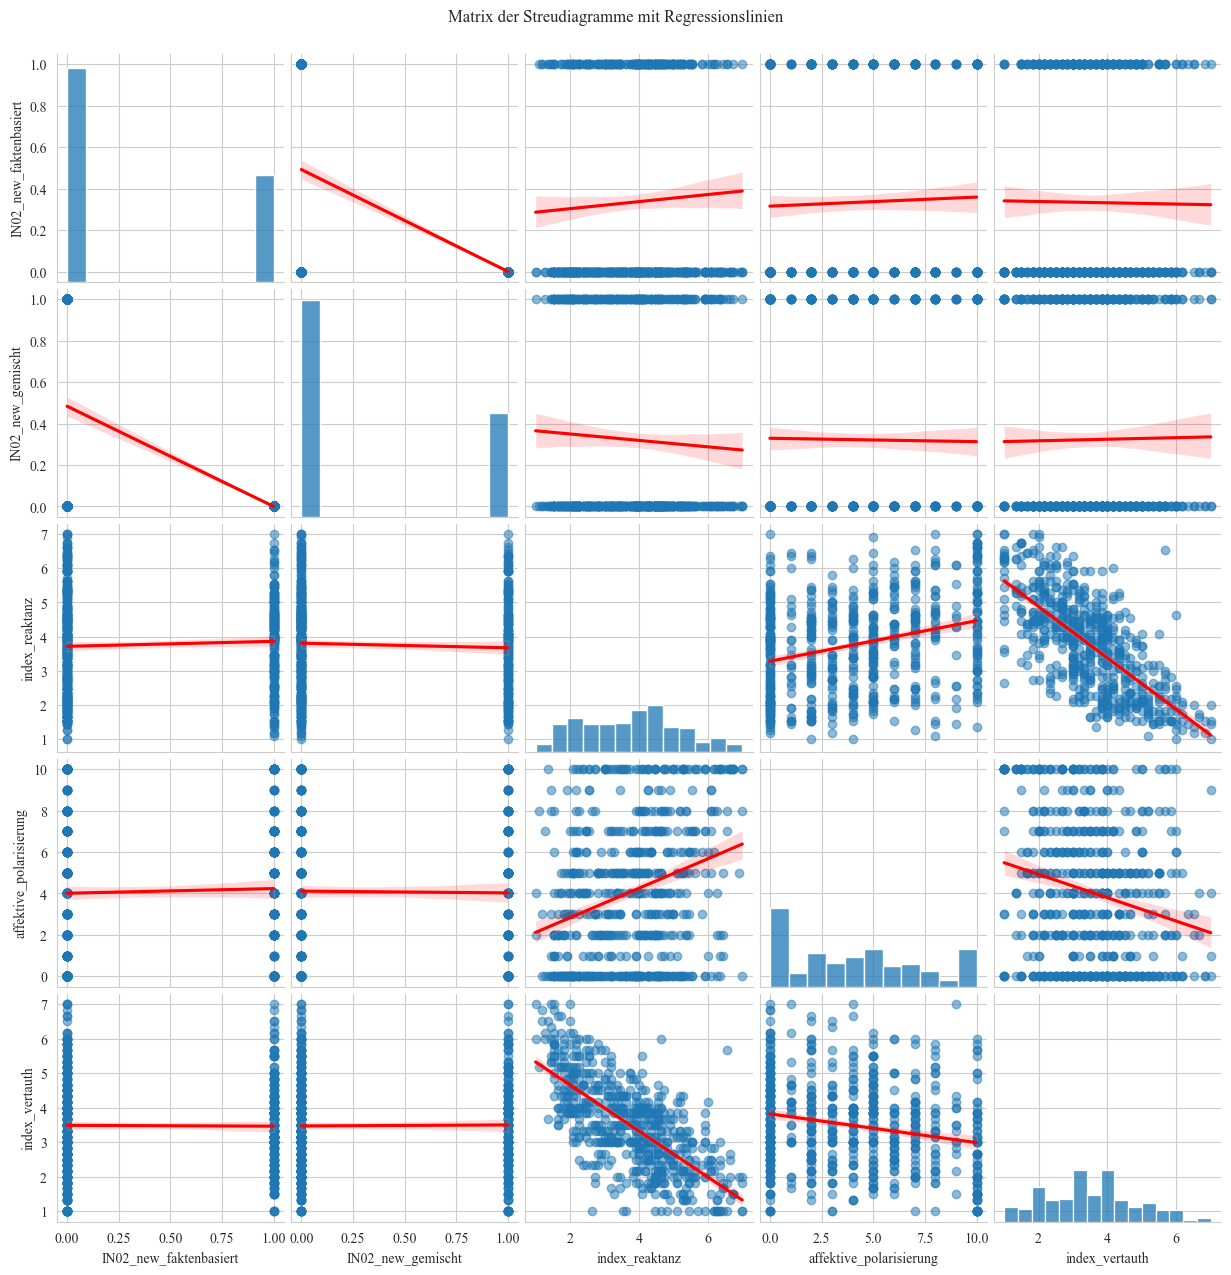

In [62]:
# Voraussetzungen prüfen für Mediationsanalyse mit Dummyvariablen "IN02_new_faktenbasiert" und "IN02_new_gemischt" als UV, Reaktanz "index_reaktanz" als Mediator, affektive Polarisierung "affektive_polarisierung" als AV und Vertrauen "index_vertauth" als Kontrollvariable
# Linearität, Normalverteilung der Residuen, Homoskedastizität, Unabhängigkeit


# Matrix der Streudiagramme (mit Loess-Regressionslinien und als Kern Gleichverteilung) -> Linearität prüfen
def plot_pairwise_relationships(df, vars):
   sns.pairplot(df[vars], kind='reg', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha':0.5}})
   plt.suptitle('Matrix der Streudiagramme mit Regressionslinien', y=1.02)
relevante_variablen = [
    "IN02_new_faktenbasiert",
    "IN02_new_gemischt",
    "index_reaktanz",
    "affektive_polarisierung",
    "index_vertauth"
]
plot_pairwise_relationships(df_masterprojekt1, relevante_variablen)
plt.show()


                               OLS Regression Results                              
Dep. Variable:     affektive_polarisierung   R-squared:                       0.085
Model:                                 OLS   Adj. R-squared:                  0.079
Method:                      Least Squares   F-statistic:                     14.86
Date:                     Sun, 11 Jan 2026   Prob (F-statistic):           1.28e-11
Time:                             17:23:24   Log-Likelihood:                -1672.8
No. Observations:                      645   AIC:                             3356.
Df Residuals:                          640   BIC:                             3378.
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

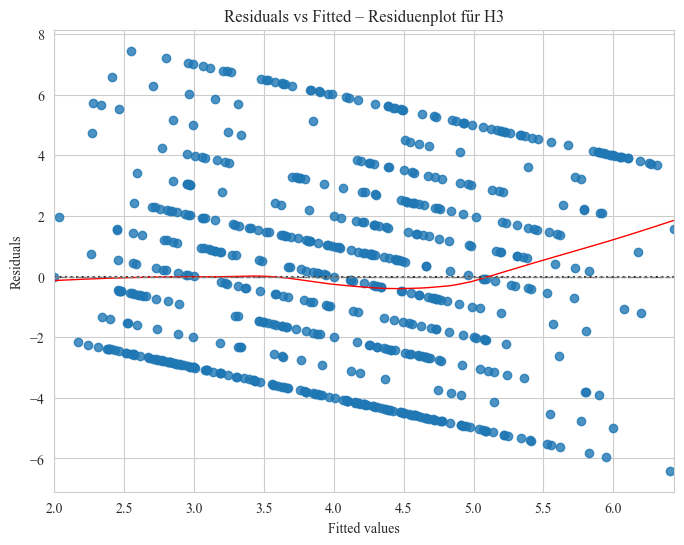

In [63]:
# Residuenplot-Funktion definieren
def plot_residuals(model, title):
    residuals = model.resid
    fitted = model.fittedvalues

    plt.figure(figsize=(8, 6))
    sns.residplot(x=fitted, y=residuals, lowess=True,
                  line_kws={'color': 'red', 'lw': 1})
    plt.title(f'Residuals vs Fitted – {title}')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    plt.axhline(0, color='grey', linestyle='--', lw=1)
    plt.show()

# Modell schätzen
model_b = smf.ols(
    "affektive_polarisierung ~ index_reaktanz + IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
    data=df_masterprojekt1
).fit()

print(model_b.summary())

plot_residuals(model_b, "Residuenplot für H3")



In [64]:
# Homoskedastizitätstest (Breusch-Pagan) -> Homoskedastizität prüfen
def breusch_pagan_test(model):
   lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(model.resid, model.model.exog)
   return pd.DataFrame({
       'Lagrange Multiplier Statistic': [lm],
       'p-Wert LM': [lm_pvalue],
       'F-Statistic': [fvalue],
       'p-Wert F': [f_pvalue]
   }).round(4)

result = breusch_pagan_test(model_b) # model_b ist das Regressionsmodell, das überprüft werden soll, den Namen habe ich aus der "# NEU" Mediationsanalyse übernommen.
print("Breusch-Pagan Test:")
print(result)

Breusch-Pagan Test:
   Lagrange Multiplier Statistic  p-Wert LM  F-Statistic  p-Wert F
0                        12.7903     0.0123        3.237    0.0121


In [65]:
# Unabhängigkeit der Residuen (Durbin-Watson) -> Unabhängigkeit prüfen
def durbin_watson_test(model):
   return durbin_watson(model.resid)
   

result = durbin_watson_test(model_b)
print(f"Durbin-Watson Statistik: {result:.4f}")

Durbin-Watson Statistik: 2.0072


In [66]:
# Überprüfen der Datentypen der relevanten Variablen

df_masterprojekt1[[
    "IN02_new_faktenbasiert",
    "IN02_new_gemischt",
    "index_reaktanz",
    "affektive_polarisierung",
    "index_vertauth"
]].dtypes

IN02_new_faktenbasiert        bool
IN02_new_gemischt             bool
index_reaktanz             float64
affektive_polarisierung      int64
index_vertauth             float64
dtype: object

In [67]:
# Überprüfen auf fehlende Werte in den relevanten Variablen

df_masterprojekt1[[
    "IN02_new_faktenbasiert",
    "IN02_new_gemischt",
    "index_reaktanz",
    "affektive_polarisierung",
    "index_vertauth"
]].isna().sum()

IN02_new_faktenbasiert     0
IN02_new_gemischt          0
index_reaktanz             0
affektive_polarisierung    0
index_vertauth             0
dtype: int64

In [68]:
df_masterprojekt1["IN02_new_faktenbasiert"] = df_masterprojekt1["IN02_new_faktenbasiert"].astype(int)
df_masterprojekt1["IN02_new_gemischt"] = df_masterprojekt1["IN02_new_gemischt"].astype(int)


In [69]:
# Hypothese H3a: Ein faktenbasierter KS eines Chatbots führt zu einer stärkeren Reaktanz als ein empathischer sowie ein gemischter KS.
# Hypothese H3b: Ein gemischter KS eines Chatbots führt zu einer geringeren Reaktanz als ein empathischer sowie faktenbasierter KS.


# ====================
# MEDIATIONSANALYSE
# ====================

print("\n====================")
print("A-PFAD: KS -> Reaktanz")
print("====================")

model_a = smf.ols(
    "index_reaktanz ~ IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
    data=df_masterprojekt1
).fit()
print(model_a.summary())

print("\n====================")
print("B-PFAD und DIREKTER EFFEKT (c'-Pfad)")
print("====================")

model_b = smf.ols(
    "affektive_polarisierung ~ index_reaktanz + IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
    data=df_masterprojekt1
).fit()
print(model_b.summary())

print("\n====================")
print("TOTALER EFFEKT (c-Pfad)")
print("====================")

model_c = smf.ols(
    "affektive_polarisierung ~ IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
    data=df_masterprojekt1
).fit()
print(model_c.summary())

# ====================
# BOOTSTRAPPING FÜR INDIREKTE EFFEKTE
# ====================

n_boot = 5000
indirect_fakten = []
indirect_gemischt = []

np.random.seed(42)

print("\nBerechne Bootstrap-Konfidenzintervalle...")

for _ in range(n_boot):
    sample = df_masterprojekt1.sample(n=len(df_masterprojekt1), replace=True)

    a_model = smf.ols(
        "index_reaktanz ~ IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
        data=sample
    ).fit()

    b_model = smf.ols(
        "affektive_polarisierung ~ index_reaktanz + IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
        data=sample
    ).fit()

    a_fakten = a_model.params["IN02_new_faktenbasiert"]
    a_gemischt = a_model.params["IN02_new_gemischt"]
    b = b_model.params["index_reaktanz"]

    indirect_fakten.append(a_fakten * b)
    indirect_gemischt.append(a_gemischt * b)

ci_fakten = np.percentile(indirect_fakten, [2.5, 97.5])
ci_gemischt = np.percentile(indirect_gemischt, [2.5, 97.5])

# ====================
# ZUSAMMENFASSUNG ALLER EFFEKTE
# ====================

print("\n" + "="*60)
print("ZUSAMMENFASSUNG DER MEDIATIONSANALYSE")
print("="*60)

print("\n" + "-"*60)
print("FAKTENBASIERT vs. EMPATHISCH (Referenz)")
print("-"*60)
print(f"  Totaler Effekt (c):        {model_c.params['IN02_new_faktenbasiert']:>8.4f}  (p = {model_c.pvalues['IN02_new_faktenbasiert']:.4f})")
print(f"  Direkter Effekt (c'):      {model_b.params['IN02_new_faktenbasiert']:>8.4f}  (p = {model_b.pvalues['IN02_new_faktenbasiert']:.4f})")
print(f"  Indirekter Effekt (a*b):   {np.mean(indirect_fakten):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_fakten[0]:.4f}, {ci_fakten[1]:.4f}]")
if ci_fakten[0] > 0 or ci_fakten[1] < 0:
    print("  -> Indirekter Effekt SIGNIFIKANT (CI schließt 0 nicht ein)")
else:
    print("  -> Indirekter Effekt NICHT signifikant (CI schließt 0 ein)")

print("\n" + "-"*60)
print("GEMISCHT vs. EMPATHISCH (Referenz)")
print("-"*60)
print(f"  Totaler Effekt (c):        {model_c.params['IN02_new_gemischt']:>8.4f}  (p = {model_c.pvalues['IN02_new_gemischt']:.4f})")
print(f"  Direkter Effekt (c'):      {model_b.params['IN02_new_gemischt']:>8.4f}  (p = {model_b.pvalues['IN02_new_gemischt']:.4f})")
print(f"  Indirekter Effekt (a*b):   {np.mean(indirect_gemischt):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_gemischt[0]:.4f}, {ci_gemischt[1]:.4f}]")
if ci_gemischt[0] > 0 or ci_gemischt[1] < 0:
    print("  -> Indirekter Effekt SIGNIFIKANT (CI schließt 0 nicht ein)")
else:
    print("  -> Indirekter Effekt NICHT signifikant (CI schließt 0 ein)")

print("\n" + "-"*60)
print("MEDIATOR-EFFEKT (b-Pfad)")
print("-"*60)
print(f"  Reaktanz -> Aff. Polarisierung: {model_b.params['index_reaktanz']:>8.4f}  (p = {model_b.pvalues['index_reaktanz']:.4f})")

print("\n" + "="*60)



A-PFAD: KS -> Reaktanz
                            OLS Regression Results                            
Dep. Variable:         index_reaktanz   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     217.1
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           3.65e-97
Time:                        17:23:50   Log-Likelihood:                -897.93
No. Observations:                 645   AIC:                             1804.
Df Residuals:                     641   BIC:                             1822.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Inte

In [70]:
# NEU

# ====================
# MEDIATION (PROCESS 4)
# ====================

# a-Pfad: KS + Vertrauen -> Reaktanz
model_a = smf.ols(
    "index_reaktanz ~ IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
    data=df_masterprojekt1
).fit()
print(model_a.summary())

# b-Pfad: Reaktanz + KS + Vertrauen -> affektive Polarisierung
model_b = smf.ols(
    "affektive_polarisierung ~ index_reaktanz + IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
    data=df_masterprojekt1
).fit()
print(model_b.summary())

# ====================
# BOOTSTRAP indirekte Effekte
# ====================

n_boot = 5000
indirect_fakten = []
indirect_gemischt = []

np.random.seed(42)

for _ in range(n_boot):
    sample = df_masterprojekt1.sample(n=len(df_masterprojekt1), replace=True)

    a_model = smf.ols(
        "index_reaktanz ~ IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
        data=sample
    ).fit()

    b_model = smf.ols(
        "affektive_polarisierung ~ index_reaktanz + IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
        data=sample
    ).fit()

    a_fakten = a_model.params["IN02_new_faktenbasiert"]
    a_gemischt = a_model.params["IN02_new_gemischt"]
    b = b_model.params["index_reaktanz"]

    indirect_fakten.append(a_fakten * b)
    indirect_gemischt.append(a_gemischt * b)

# 95% Bootstrap-CI
ci_fakten = np.percentile(indirect_fakten, [2.5, 97.5])
ci_gemischt = np.percentile(indirect_gemischt, [2.5, 97.5])

print("\n====================")
print("INDIREKTE EFFEKTE")
print("====================")
print("Indirekter Effekt FAKTENBASIERT vs. EMPATHISCH:", np.mean(indirect_fakten))
print("95% CI:", ci_fakten)

print("\nIndirekter Effekt GEMISCHT vs. EMPATHISCH:", np.mean(indirect_gemischt))
print("95% CI:", ci_gemischt)


                            OLS Regression Results                            
Dep. Variable:         index_reaktanz   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     217.1
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           3.65e-97
Time:                        17:25:38   Log-Likelihood:                -897.93
No. Observations:                 645   AIC:                             1804.
Df Residuals:                     641   BIC:                             1822.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  6

### Forschungsfrage 1

In [71]:
# Voraussetzungen für MANOVA prüfen ("IN02_new" als UV, "index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung" als AVs)
# Multivariate Normalverteilung, Homogenität der Kovarianzmatrizen, Unabhängigkeit der Beobachtungen, keine perfekte Multikollinearität

# 1. Multivariate Normalverteilung prüfen - KORRIGIERT
def check_multivariate_normality(df, group_col, av_cols):
    groups = df[group_col].unique()
    for group in groups:
        print(f'\nGruppe: {group}')
        subset = df[df[group_col] == group]
        
        # KORREKTUR: Jede Variable einzeln testen
        for av in av_cols:
            data = subset[av].dropna()
            if len(data) >= 3:
                stat, p = shapiro(data)
                normal = "✓ Normal" if p > 0.05 else "✗ Nicht normal"
                print(f'  {av}: Stat={stat:.4f}, p={p:.4f} - {normal}')

check_multivariate_normality(df_masterprojekt1, 'IN02_new', 
    ['index_affreaktanz', 'index_kogreaktanz', 'index_freiheitseinschraenkung'])

# 2. Homogenität der Kovarianzmatrizen prüfen - KORRIGIERT
def box_m_test(df, group_col, av_cols):
    try:
        # KORREKTUR: C() für kategoriale Variable hinzugefügt
        formula = f"{' + '.join(av_cols)} ~ C({group_col})"
        manova = MANOVA.from_formula(formula, data=df)
        result = manova.mv_test()
        print("MANOVA Ergebnisse:")
        print(result)
        
        # Zusätzlich: Levene's Test für jede Variable
        print("\nLevene's Test (Varianzhomogenität):")
        groups = df[group_col].unique()
        for av in av_cols:
            group_data = [df[df[group_col] == group][av].dropna() for group in groups]
            stat, p = levene(*group_data)
            homogen = "✓ Homogen" if p > 0.05 else "✗ Heterogen"
            print(f"  {av}: p={p:.4f} - {homogen}")
            
    except Exception as e:
        print(f"Fehler: {e}")

box_m_test(df_masterprojekt1, 'IN02_new', 
    ['index_affreaktanz', 'index_kogreaktanz', 'index_freiheitseinschraenkung'])

# 3. Unabhängigkeit der Beobachtungen prüfen
print("\n3. UNABHÄNGIGKEIT DER BEOBACHTUNGEN:")
print("✓ Durch Studiendesign gewährleistet (verschiedene Personen)")

# 4. Keine perfekte Multikollinearität prüfen
print("\n4. MULTIKOLLINEARITÄT:")
av_cols = ['index_affreaktanz', 'index_kogreaktanz', 'index_freiheitseinschraenkung']
corr_matrix = df_masterprojekt1[av_cols].corr()
print(corr_matrix.round(3))

# Interpretation
print("\nInterpretation:")
high_corr = False
for i in range(len(av_cols)):
    for j in range(i+1, len(av_cols)):
        corr_val = abs(corr_matrix.iloc[i, j])
        if corr_val > 0.8:
            print(f"⚠️ HOHE Korrelation: {av_cols[i]} - {av_cols[j]} = {corr_val:.3f}")
            high_corr = True

if not high_corr:
    print("✓ Keine problematischen Korrelationen (alle < 0.8)")



Gruppe: empathisch
  index_affreaktanz: Stat=0.9221, p=0.0000 - ✗ Nicht normal
  index_kogreaktanz: Stat=0.9655, p=0.0000 - ✗ Nicht normal
  index_freiheitseinschraenkung: Stat=0.9363, p=0.0000 - ✗ Nicht normal

Gruppe: faktenbasiert
  index_affreaktanz: Stat=0.9324, p=0.0000 - ✗ Nicht normal
  index_kogreaktanz: Stat=0.9584, p=0.0000 - ✗ Nicht normal
  index_freiheitseinschraenkung: Stat=0.9675, p=0.0001 - ✗ Nicht normal

Gruppe: gemischt
  index_affreaktanz: Stat=0.9077, p=0.0000 - ✗ Nicht normal
  index_kogreaktanz: Stat=0.9605, p=0.0000 - ✗ Nicht normal
  index_freiheitseinschraenkung: Stat=0.9353, p=0.0000 - ✗ Nicht normal
MANOVA Ergebnisse:
                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept        Value  Num DF  Den DF   F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.1636 3.0000 640.0

In [72]:
# Forschungsfrage 1: Inwiefern beeinflussen die drei KS eines Chatbots (empathisch, faktenbasiert, gemischt) 
# die drei Reaktanz-Dimensionen(wahrgenommene Freiheitseinschränkung, Emotion, Kognition)?

# MANOVA - UV: Kommunikationsstile (faktenbasiert, empathisch, gemischt) & AV: drei Reaktanz-Dimensionen
# Listen erstellen
avs_manova = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"] # Liste der AVs
cols_manova = ["IN02_new", *avs_manova] # kombinierte Liste mit UV und AVs (fyi das * entpackt die Liste)

# Vrbereitung der Datem für den Test
df_manova = df_masterprojekt1[cols_manova].copy() # Unterdatensatz mit genau den Spalten, die wir für die Analyse brauchen
df_manova[avs_manova] = df_manova[avs_manova].apply(pd.to_numeric, errors="coerce") # AVs in numerische Typen umwandeln
df_manova = df_manova.dropna(subset=["IN02_new", *avs_manova]) # Zeilen mit fehlenden AVs entfernen
df_manova["IN02_new"] = df_manova["IN02_new"].astype("category") # Gruppierungsvariable als kategorial setzen

# Überblick
print(f"n = {len(df_manova)}") # Stichprobengröße
print(df_manova["IN02_new"].value_counts().sort_index()) # Gruppengrößen je Kommunikationsstil  
print(df_manova.groupby("IN02_new")[avs_manova].agg(["mean", "std", "count"]).round(3)) # Deskriptive Statistiken (M, SD, n) je KS und AV

# MANOVA
results_manova = MANOVA.from_formula( # Formel 
    "index_affreaktanz + index_kogreaktanz + index_freiheitseinschraenkung ~ C(IN02_new)", # fyi das C erzwingt kategorial; mv_test berechnet die multivariaten Tests (Pillai, Wilks, Hotelling, Roy)
    data=df_manova
).mv_test()
print(results_manova) # liefert F-Werte, df und p-Wert für den Haupteffekt der KS auf die drei AVs


n = 645
IN02_new
empathisch       222
faktenbasiert    215
gemischt         208
Name: count, dtype: int64
              index_affreaktanz              index_kogreaktanz               \
                           mean    std count              mean    std count   
IN02_new                                                                      
empathisch                3.291  1.859   222             4.977  1.337   222   
faktenbasiert             3.479  1.778   215             5.073  1.262   215   
gemischt                  3.056  1.809   208             5.079  1.301   208   

              index_freiheitseinschraenkung               
                                       mean    std count  
IN02_new                                                  
empathisch                            3.309  1.786   222  
faktenbasiert                         3.341  1.465   215  
gemischt                              3.238  1.761   208  
                   Multivariate linear model
                    

In [73]:
# nächster Schritt bei Signifikanz: Univariate ANOVA & Post-hoc Tests rechnen

avs_anovaF1 = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"] # Liste der AVs für univariate ANOVA
anova_rows_f1, tukey_results_f1 = [], {} # Container für kompakte ANOVA-Übersicht

for av in avs_anovaF1: # Schleife: gleiches Vorgehen je AV
    model_f1 = ols(f"{av} ~ C(IN02_new)", data=df_manova).fit() # OLS-Modell pro AV mit kategorialer UV (siehe C)
    anova_f1 = anova_lm(model_f1, typ=2)
    p_val = anova_f1.loc["C(IN02_new)", "PR(>F)"]
    eta2 = anova_f1.loc["C(IN02_new)", "sum_sq"] / anova_f1["sum_sq"].sum()
    
    anova_rows_f1.append({
        "AV": av,
        "F": anova_f1.loc["C(IN02_new)", "F"],
        "p": p_val,
        "eta²": eta2
    }) 
 
anova_table_f1 = pd.DataFrame(anova_rows_f1) # Ergebnistabelle 
print("\nANOVA-Übersicht (F1):")
print(anova_table_f1.round(3))

# Post-hoc Tests ergänzen (vorab: Levene-Test auf Varianzhomogenität) -> Welch-Test, Games Howell


ANOVA-Übersicht (F1):
                              AV      F      p   eta²
0              index_affreaktanz  2.870  0.057  0.009
1              index_kogreaktanz  0.416  0.660  0.001
2  index_freiheitseinschraenkung  0.207  0.813  0.001


In [74]:
# nächster Schritt bei Signifikanz: Univariate ANOVA & Post-hoc Tests rechnen

avs_anovaF1 = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"]

anova_rows_f1 = []
tukey_results_f1 = {}

for av in avs_anovaF1:
    print(f"\n===== ANOVA für {av} =====")

    # OLS-Modell
    model_f1 = ols(f"{av} ~ C(IN02_new)", data=df_manova).fit()
    anova_f1 = anova_lm(model_f1, typ=2)
    print(anova_f1)

    # Effektstärke eta²
    ss_effect = anova_f1.loc["C(IN02_new)", "sum_sq"]
    ss_total = anova_f1["sum_sq"].sum()
    eta2 = ss_effect / ss_total
    p_val = anova_f1.loc["C(IN02_new)", "PR(>F)"]

    anova_rows_f1.append({
        "AV": av,
        "F": anova_f1.loc["C(IN02_new)", "F"],
        "p": p_val,
        "eta²": eta2
    })

    # Nur Tukey, wenn ANOVA signifikant
    if p_val < 0.05:
        tukey = pairwise_tukeyhsd(
            endog=df_manova[av],
            groups=df_manova["IN02_new"],
            alpha=0.05
        )
        tukey_results_f1[av] = tukey
        print("\nTukey-HSD:")
        print(tukey.summary())

# kompakte Übersicht aller drei ANOVAs
anova_overview_f1 = pd.DataFrame(anova_rows_f1).round(4)
print("\n\nÜbersicht ANOVAs Forschungsfrage 1:")
print(anova_overview_f1.to_string(index=False))



===== ANOVA für index_affreaktanz =====
                  sum_sq     df         F    PR(>F)
C(IN02_new)    18.932987    2.0  2.870376  0.057405
Residual     2117.314687  642.0       NaN       NaN

===== ANOVA für index_kogreaktanz =====
                  sum_sq     df         F    PR(>F)
C(IN02_new)     1.406568    2.0  0.415746  0.660025
Residual     1086.018755  642.0       NaN       NaN

===== ANOVA für index_freiheitseinschraenkung =====
                  sum_sq     df         F    PR(>F)
C(IN02_new)     1.164565    2.0  0.207041  0.813041
Residual     1805.565086  642.0       NaN       NaN


Übersicht ANOVAs Forschungsfrage 1:
                           AV      F      p   eta²
            index_affreaktanz 2.8704 0.0574 0.0089
            index_kogreaktanz 0.4157 0.6600 0.0013
index_freiheitseinschraenkung 0.2070 0.8130 0.0006


In [75]:

# nächster Schritt bei Signifikanz: Univariate ANOVA & Post-hoc Tests rechnen (Tukey-HSD + Games-Howell)

%pip install -q scikit-posthocs


avs_anovaF1 = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"]

anova_rows_f1 = []
posthoc_results = {}

for av in avs_anovaF1:
    print(f"\n===== ANALYSE für {av} =====")

    # Dropna für die aktuelle AV + Gruppenvariable
    df_tmp = df_manova[[av, "IN02_new"]].dropna().copy()
    groups = df_tmp["IN02_new"].unique().tolist()
    print(f"Beobachtungen gesamt: {len(df_tmp)}, Gruppen: {groups}")

    # Levene-Test auf Varianz-Homogenität
    lev_groups = [df_tmp.loc[df_tmp["IN02_new"] == g, av].values for g in df_tmp["IN02_new"].cat.categories]
    stat_lev, p_lev = levene(*lev_groups, center="mean")
    print(f"Levene: W = {stat_lev:.4f}, p = {p_lev:.4f}  {'(Heterogenität!)' if p_lev<0.05 else '(homogen)'}")

    # klassische ANOVA 
    model_f1 = ols(f"{av} ~ C(IN02_new)", data=df_tmp).fit()
    anova_f1 = anova_lm(model_f1, typ=2)
    print("\nANOVA:")
    print(anova_f1)

    # Effektstärke eta²
    ss_effect = anova_f1.loc["C(IN02_new)", "sum_sq"]
    ss_total = anova_f1["sum_sq"].sum()
    eta2 = ss_effect / ss_total if ss_total > 0 else np.nan
    p_val = anova_f1.loc["C(IN02_new)", "PR(>F)"]

    anova_rows_f1.append({
        "AV": av,
        "F": anova_f1.loc["C(IN02_new)", "F"],
        "p": p_val,
        "eta²": eta2
    })

    # Tukey-HSD (paarweise Vergleiche) — Hinweis: setzt Varianzhomogenität voraus
    try:
        tukey = pairwise_tukeyhsd(endog=df_tmp[av], groups=df_tmp["IN02_new"], alpha=0.05)
        print("\nTukey-HSD (paarweise Vergleiche):")
        print(tukey.summary())
        tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    except Exception as e:
        print("\nTukey-HSD konnte nicht berechnet werden:", e)
        tukey_df = None


    # Zusammenfassen der Post-hoc Ergebnisse für diese AV
    posthoc_results[av] = {
        "tukey": tukey_df
    }

# kompakte Übersicht aller drei ANOVAs
anova_overview_f1 = pd.DataFrame(anova_rows_f1).round(4)
print("\n\nÜbersicht ANOVAs Forschungsfrage 1:")
print(anova_overview_f1.to_string(index=False))


Note: you may need to restart the kernel to use updated packages.

===== ANALYSE für index_affreaktanz =====
Beobachtungen gesamt: 645, Gruppen: ['empathisch', 'faktenbasiert', 'gemischt']
Levene: W = 0.5491, p = 0.5778  (homogen)

ANOVA:
                  sum_sq     df         F    PR(>F)
C(IN02_new)    18.932987    2.0  2.870376  0.057405
Residual     2117.314687  642.0       NaN       NaN

Tukey-HSD (paarweise Vergleiche):
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
   empathisch faktenbasiert   0.1885 0.5238 -0.2197  0.5967  False
   empathisch      gemischt  -0.2341  0.376 -0.6457  0.1776  False
faktenbasiert      gemischt  -0.4226 0.0448 -0.8375 -0.0077   True
------------------------------------------------------------------

===== ANALYSE für index_kogreaktanz =====
Beobachtungen gesamt: 645, Gruppen: ['empathisch', 'fakten

# Zusätzliche Analyse: nur mit den moderaten Fällen rechnen

In [76]:
# neue Variable erzeugen
df_masterprojekt1["IN02_moderat"] = df_masterprojekt1["IN02"].map({
    1: "faktenbasiert",
    2: "gemischt",
    3: "empathisch"
})

# als Kategorie setzen
df_masterprojekt1["IN02_moderat"] = df_masterprojekt1["IN02_moderat"].astype("category")


In [77]:
df_mod = df_masterprojekt1[df_masterprojekt1["IN02_moderat"].notna()].copy()

In [78]:
print(df_mod["IN02_moderat"].value_counts())

IN02_moderat
empathisch       110
faktenbasiert    107
gemischt         107
Name: count, dtype: int64


In [79]:
print(df_mod["IN02_moderat"].value_counts())

IN02_moderat
empathisch       110
faktenbasiert    107
gemischt         107
Name: count, dtype: int64


### Reporting Interaktionseffekt

In [80]:
# neue Variable erzeugen
df_masterprojekt1["IN02_extrem"] = df_masterprojekt1["IN02"].map({
    4: "faktenbasiert",
    5: "gemischt",
    6: "empathisch"
})

# als Kategorie setzen
df_masterprojekt1["IN02_extremt"] = df_masterprojekt1["IN02_extrem"].astype("category")


In [81]:
df_extr = df_masterprojekt1[df_masterprojekt1["IN02_extrem"].notna()].copy()

In [82]:
print(df_extr["IN02_extrem"].value_counts())

IN02_extrem
empathisch       112
faktenbasiert    108
gemischt         101
Name: count, dtype: int64


In [83]:
# Deskriptive Statistik für die moderaten und extremen Fälle (empathisch)

desc_emp_ext = (
    df_masterprojekt1
    .groupby(["IN02_new", "IN02_extremität"])["index_check_empathisch"]
    .agg(N="count", M="mean", SD="std")
    .round(2)
    .reset_index()
)

desc_emp_ext




,IN02_new,IN02_extremität,N,M,SD
0,empathisch,extrem,112,2.96,1.56
1,empathisch,moderat,110,4.57,1.42
2,faktenbasiert,extrem,108,3.02,1.52
3,faktenbasiert,moderat,107,3.82,1.61
4,gemischt,extrem,101,3.39,1.71
5,gemischt,moderat,107,4.16,1.63


In [84]:
# Deskriptive Statistik für die moderaten und extremen Fälle (faktenbasiert)

desc_emp_ext = (
    df_masterprojekt1
    .groupby(["IN02_new", "IN02_extremität"])["index_check_faktenbasiert"]
    .agg(N="count", M="mean", SD="std")
    .round(2)
    .reset_index()
)

desc_emp_ext


,IN02_new,IN02_extremität,N,M,SD
0,empathisch,extrem,112,3.34,1.55
1,empathisch,moderat,110,4.10,1.50
2,faktenbasiert,extrem,108,3.96,1.54
3,faktenbasiert,moderat,107,4.91,1.37
4,gemischt,extrem,101,3.90,1.64
5,gemischt,moderat,107,4.60,1.46


In [85]:
# Deskriptive Statistik für die moderaten und extremen Fälle (gemischt)

desc_emp_ext = (
    df_masterprojekt1
    .groupby(["IN02_new", "IN02_extremität"])["index_check_gemischt"]
    .agg(N="count", M="mean", SD="std")
    .round(2)
    .reset_index()
)

desc_emp_ext

,IN02_new,IN02_extremität,N,M,SD
0,empathisch,extrem,112,3.15,1.38
1,empathisch,moderat,110,4.33,1.21
2,faktenbasiert,extrem,108,3.49,1.32
3,faktenbasiert,moderat,107,4.36,1.30
4,gemischt,extrem,101,3.64,1.53
5,gemischt,moderat,107,4.38,1.35


## Manipulationscheck

In [86]:
# Manipulationscheck nur mit den moderaten Fällen
def run_anova(df_manipulationscheck, av, title, style_var):  
    print(f"\n===== {title} =====\n")

    df_ = df_manipulationscheck[[av, style_var]].dropna().copy()
    df_[style_var] = df_[style_var].astype('category')

    print("Deskriptive Werte:")
    print(df_.groupby(style_var)[av].agg(['count','mean','std']), "\n")

    model = ols(f'{av} ~ C({style_var})', data=df_).fit()
    print("ANOVA:")
    print(anova_lm(model, typ=2), "\n")

    groups = df_[style_var].cat.categories
    pairs = list(it.combinations(groups, 2))

    results = []
    for g1, g2 in pairs:
        x = df_.loc[df_[style_var] == g1, av]
        y = df_.loc[df_[style_var] == g2, av]
        t, p = ttest_ind(x, y, equal_var=False)
        results.append([g1, g2, x.mean(), y.mean(), p])

    results = pd.DataFrame(results, columns=['g1','g2','m1','m2','p_unc'])
    results['p_bonf'] = multipletests(results['p_unc'], method='bonferroni')[1]

    print("Post-hoc (Bonferroni):")
    print(results, "\n")

run_anova(df_mod, "index_check_empathisch",    "Block 1: Empathischer Manipulationscheck (moderat)", "IN02_moderat")
run_anova(df_mod, "index_check_faktenbasiert", "Block 2: Faktenbasierter Manipulationscheck (moderat)", "IN02_moderat")
run_anova(df_mod, "index_check_gemischt",      "Block 3: Gemischter Manipulationscheck (moderat)", "IN02_moderat")



===== Block 1: Empathischer Manipulationscheck (moderat) =====

Deskriptive Werte:
               count      mean       std
IN02_moderat                            
empathisch       110  4.572727  1.423648
faktenbasiert    107  3.817757  1.605404
gemischt         107  4.158879  1.631931 

ANOVA:
                     sum_sq     df         F    PR(>F)
C(IN02_moderat)   31.039423    2.0  6.416462  0.001852
Residual         776.413509  321.0       NaN       NaN 

Post-hoc (Bonferroni):
              g1             g2        m1        m2     p_unc    p_bonf
0     empathisch  faktenbasiert  4.572727  3.817757  0.000317  0.000951
1     empathisch       gemischt  4.572727  4.158879  0.048060  0.144180
2  faktenbasiert       gemischt  3.817757  4.158879  0.124713  0.374138 


===== Block 2: Faktenbasierter Manipulationscheck (moderat) =====

Deskriptive Werte:
               count      mean       std
IN02_moderat                            
empathisch       110  4.095455  1.503048
faktenbasier

- neue Erkenntnis: Tatsächlich wird der empathische KS in der moderaten Bedingung deutlich besser als solcher erkannt -> siehe Signifikanz 
- die gemischte Bedingung bleibt nicht-signifikant im Manipulationscheck

## Tests rechnen

### H1

In [87]:
# H1 

# Daten: NUR moderate Fälle + neue Variable
df_anovaH1 = df_mod[['affektive_polarisierung', 'IN02_moderat']].dropna().copy()
df_anovaH1['IN02_moderat'] = df_anovaH1['IN02_moderat'].astype('category')

# Deskriptive Werte je Kommunikationsstil
print("--- Deskriptive Statistiken ---")
print(df_anovaH1.groupby('IN02_moderat')['affektive_polarisierung']
      .agg(['count','mean','std']).round(4))
print("\n")

# ANOVA
modelH1 = ols('affektive_polarisierung ~ C(IN02_moderat)', data=df_anovaH1).fit()
anova_table = anova_lm(modelH1, typ=2)

# Eta-Quadrat (n^2) berechnen
# Berechnung: SS_effect / (SS_effect + SS_residual)
anova_table['eta_sq'] = anova_table['sum_sq'] / (anova_table['sum_sq'].sum())

print("--- ANOVA Tabelle mit Eta-Quadrat ---")
print(anova_table.round(4))
print("\n")

# Post-hoc (Welch + Bonferroni)
groupsH1 = df_anovaH1['IN02_moderat'].cat.categories.tolist()
pairs = list(it.combinations(groupsH1, 2))

results = []
for g1, g2 in pairs:
    x = df_anovaH1.loc[df_anovaH1['IN02_moderat'] == g1, 'affektive_polarisierung']
    y = df_anovaH1.loc[df_anovaH1['IN02_moderat'] == g2, 'affektive_polarisierung']
    t, p = ttest_ind(x, y, equal_var=False, nan_policy='omit')
    results.append({
        'g1': g1, 'g2': g2,
        'n1': x.size, 'n2': y.size,
        'm1': x.mean(), 'm2': y.mean(),
        't': t, 'p_unc': p
    })

p_adj = multipletests([r['p_unc'] for r in results], method='bonferroni')

for r, p_b, sig in zip(results, p_adj[1], p_adj[0]):
    r['p_bonf'] = p_b
    r['sig_bonf'] = sig

posthoc_df = pd.DataFrame(results).sort_values('p_bonf')
print("--- Post-hoc Ergebnisse ---")
print(posthoc_df[['g1','g2','n1','n2','m1','m2','t','p_unc','p_bonf','sig_bonf']].round(4))

--- Deskriptive Statistiken ---
               count    mean     std
IN02_moderat                        
empathisch       110  3.7727  3.3364
faktenbasiert    107  4.1776  3.1166
gemischt         107  4.2523  3.4480


--- ANOVA Tabelle mit Eta-Quadrat ---
                    sum_sq     df       F  PR(>F)  eta_sq
C(IN02_moderat)    14.5076    2.0  0.6647  0.5151  0.0041
Residual         3503.1313  321.0     NaN     NaN  0.9959


--- Post-hoc Ergebnisse ---
              g1             g2   n1   n2      m1      m2       t   p_unc  \
1     empathisch       gemischt  110  107  3.7727  4.2523 -1.0409  0.2991   
0     empathisch  faktenbasiert  110  107  3.7727  4.1776 -0.9240  0.3565   
2  faktenbasiert       gemischt  107  107  4.1776  4.2523 -0.1664  0.8680   

   p_bonf  sig_bonf  
1  0.8973     False  
0  1.0000     False  
2  1.0000     False  


### H3

In [88]:
# H3

# Die Beziehung zwischen dem KS eines Chatbots und der affektiven Polarisierung wird durch die Reaktanz mediierend beeinflusst, wenn das Vertrauen in den Chatbot kontrolliert wird.

# Dummyvariablen für den Kommunikationsstil (IN02_moderat) erstellen, falls noch nicht vorhanden
if 'IN02_moderat' in df_masterprojekt1.columns:
    # 1. Dummys separat generieren (auf die Spalte direkt angewendet)
    dummies = pd.get_dummies(df_mod['IN02_moderat'], prefix='IN02_moderat', drop_first=True)
    
    # 2. Die Dummys an den ursprünglichen DataFrame anhängen
    df_mod = pd.concat([df_mod, dummies], axis=1)
else:
    print("Spalte IN02_moderat nicht gefunden oder Dummys bereits vorhanden.")

print(df_masterprojekt1.columns)

Index(['CASE', 'SERIAL', 'REF', 'QUESTNNR', 'MODE', 'STARTED', 'CH01_01',
       'ID01_RV1', 'IN02_CP', 'IN02',
       ...
       'PT07_new', 'index_check_empathisch', 'index_check_faktenbasiert',
       'index_check_gemischt', 'IN02_extremität', 'IN02_new_faktenbasiert',
       'IN02_new_gemischt', 'IN02_moderat', 'IN02_extrem', 'IN02_extremt'],
      dtype='object', length=246)


In [89]:
# Konvertiere die Dummy-Variablen von bool nach int64
df_mod["IN02_moderat_faktenbasiert"] = df_mod["IN02_moderat_faktenbasiert"].astype("int64")
df_mod["IN02_moderat_gemischt"] = df_mod["IN02_moderat_gemischt"].astype("int64")

# Kontrolle: dtypes anzeigen
df_mod[["IN02_moderat_faktenbasiert", "IN02_moderat_gemischt"]].dtypes

IN02_moderat_faktenbasiert    int64
IN02_moderat_gemischt         int64
dtype: object

In [90]:
# Überprüfen der Datentypen der relevanten Variablen

df_mod[[
    "IN02_moderat_faktenbasiert",
    "IN02_moderat_gemischt",
    "index_reaktanz",
    "affektive_polarisierung",
    "index_vertauth"
]].dtypes

IN02_moderat_faktenbasiert      int64
IN02_moderat_gemischt           int64
index_reaktanz                float64
affektive_polarisierung         int64
index_vertauth                float64
dtype: object

In [91]:
# Hypothese H3a:Ein faktenbasierter KS eines Chatbots führt zu einer stärkeren Reaktanz als ein empathischer sowie ein gemischter KS.
# Hypothese H3b:Ein gemischter KS eines Chatbots führt zu einer geringeren Reaktanz als ein empathischer sowie faktenbasierter KS. 

# 1. a- und b-Pfad Modelle
# a-Pfad: Regressionsmodell mit UV (KS) und Kontrollvariable (Vertrauen) auf Mediator (Reaktanz)

model_a = smf.ols(
    "index_reaktanz ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_a.summary())

# b-Pfad: Regressionsmodell mit Mediator (Reaktanz), UV (KS) und Kontrollvariable (Vertrauen) auf AV (affektive Polarisierung)

model_b = smf.ols(
    "affektive_polarisierung ~ index_reaktanz + IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_b.summary())

# 2. Bootstrapping für indirekte Effekte

n_boot = 5000 # Anzahl der Bootstrap-Stichproben
indirect_fakten = []
indirect_gemischt = []

np.random.seed(42) # für Reproduzierbarkeit

for _ in range(n_boot): # Schleife über die Anzahl der Bootstrap-Stichproben
    sample = df_mod.sample(n=len(df_mod), replace=True) # Bootstrap-Stichprobe ziehen

    a_model = smf.ols( # a-Pfad in der Bootstrap-Stichprobe
        "index_reaktanz ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
        data=sample
    ).fit()

    b_model = smf.ols( # b-Pfad in der Bootstrap-Stichprobe
        "affektive_polarisierung ~ index_reaktanz + IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
        data=sample
    ).fit()

    a_fakten = a_model.params["IN02_moderat_faktenbasiert"] # a-Pfad Koeffizient für faktenbasiert
    a_gemischt = a_model.params["IN02_moderat_gemischt"] # a-Pfad Koeffizient für gemischt

    b = b_model.params["index_reaktanz"] # b-Pfad Koeffizient

    indirect_fakten.append(a_fakten * b) # indirekter Effekt faktenbasiert
    indirect_gemischt.append(a_gemischt * b) # indirekter Effekt gemischt

# 3. Confidence Intervals für indirekte Effekte

ci_fakten = np.percentile(indirect_fakten, [2.5, 97.5]) # 95% CI für faktenbasiert
ci_gemischt = np.percentile(indirect_gemischt, [2.5, 97.5]) # 95% CI für gemischt

print("\n====================")
print("INDIREKTE EFFEKTE")
print("====================")

print("Indirekter Effekt FAKTENBASIERT vs. EMPATHISCH:", np.mean(indirect_fakten))
print("95% CI:", ci_fakten)

print("\nIndirekter Effekt GEMISCHT vs. EMPATHISCH:", np.mean(indirect_gemischt))
print("95% CI:", ci_gemischt)

                            OLS Regression Results                            
Dep. Variable:         index_reaktanz   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     88.95
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           7.02e-42
Time:                        17:28:27   Log-Likelihood:                -428.39
No. Observations:                 324   AIC:                             864.8
Df Residuals:                     320   BIC:                             879.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [92]:
# Hypothese H3a: Ein faktenbasierter KS eines Chatbots führt zu einer stärkeren Reaktanz als ein empathischer sowie ein gemischter KS.
# Hypothese H3b: Ein gemischter KS eines Chatbots führt zu einer geringeren Reaktanz als ein empathischer sowie faktenbasierter KS. 

# ====================
# MEDIATIONSANALYSE
# ====================

# 1. a-Pfad: UV (KS) -> Mediator (Reaktanz)
print("\n====================")
print("A-PFAD: KS -> Reaktanz")
print("====================")

model_a = smf.ols(
    "index_reaktanz ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_a.summary())

# 2. b-Pfad und c'-Pfad: UV (KS) + Mediator (Reaktanz) -> AV (affektive Polarisierung)
print("\n====================")
print("B-PFAD und DIREKTER EFFEKT (c'-Pfad)")
print("====================")

model_b = smf.ols(
    "affektive_polarisierung ~ index_reaktanz + IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_b.summary())

# 3. c-Pfad: Totaler Effekt UV (KS) -> AV (affektive Polarisierung)
print("\n====================")
print("TOTALER EFFEKT (c-Pfad)")
print("====================")

model_c = smf.ols(
    "affektive_polarisierung ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_c.summary())

# ====================
# BOOTSTRAPPING FÜR INDIREKTE EFFEKTE
# ====================

n_boot = 5000
indirect_fakten = []
indirect_gemischt = []

np.random.seed(42)

print("\nBerechne Bootstrap-Konfidenzintervalle...")

for _ in range(n_boot):
    sample = df_mod.sample(n=len(df_mod), replace=True)
    
    a_model = smf.ols(
        "index_reaktanz ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
        data=sample
    ).fit()
    
    b_model = smf.ols(
        "affektive_polarisierung ~ index_reaktanz + IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
        data=sample
    ).fit()
    
    a_fakten = a_model.params["IN02_moderat_faktenbasiert"]
    a_gemischt = a_model.params["IN02_moderat_gemischt"]
    b = b_model.params["index_reaktanz"]
    
    indirect_fakten.append(a_fakten * b)
    indirect_gemischt.append(a_gemischt * b)

# Konfidenzintervalle berechnen
ci_fakten = np.percentile(indirect_fakten, [2.5, 97.5])
ci_gemischt = np.percentile(indirect_gemischt, [2.5, 97.5])

# ====================
# ZUSAMMENFASSUNG ALLER EFFEKTE
# ====================

print("\n" + "="*60)
print("ZUSAMMENFASSUNG DER MEDIATIONSANALYSE")
print("="*60)

print("\n" + "-"*60)
print("FAKTENBASIERT vs. EMPATHISCH (Referenz)")
print("-"*60)
print(f"  Totaler Effekt (c):        {model_c.params['IN02_moderat_faktenbasiert']:>8.4f}  (p = {model_c.pvalues['IN02_moderat_faktenbasiert']:.4f})")
print(f"  Direkter Effekt (c'):      {model_b.params['IN02_moderat_faktenbasiert']:>8.4f}  (p = {model_b.pvalues['IN02_moderat_faktenbasiert']:.4f})")
print(f"  Indirekter Effekt (a*b):   {np.mean(indirect_fakten):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_fakten[0]:.4f}, {ci_fakten[1]:.4f}]")
if ci_fakten[0] > 0 or ci_fakten[1] < 0:
    print("  -> Indirekter Effekt SIGNIFIKANT (CI schließt 0 nicht ein)")
else:
    print("  -> Indirekter Effekt NICHT signifikant (CI schließt 0 ein)")

print("\n" + "-"*60)
print("GEMISCHT vs. EMPATHISCH (Referenz)")
print("-"*60)
print(f"  Totaler Effekt (c):        {model_c.params['IN02_moderat_gemischt']:>8.4f}  (p = {model_c.pvalues['IN02_moderat_gemischt']:.4f})")
print(f"  Direkter Effekt (c'):      {model_b.params['IN02_moderat_gemischt']:>8.4f}  (p = {model_b.pvalues['IN02_moderat_gemischt']:.4f})")
print(f"  Indirekter Effekt (a*b):   {np.mean(indirect_gemischt):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_gemischt[0]:.4f}, {ci_gemischt[1]:.4f}]")
if ci_gemischt[0] > 0 or ci_gemischt[1] < 0:
    print("  -> Indirekter Effekt SIGNIFIKANT (CI schließt 0 nicht ein)")
else:
    print("  -> Indirekter Effekt NICHT signifikant (CI schließt 0 ein)")

print("\n" + "-"*60)
print("MEDIATOR-EFFEKT (b-Pfad)")
print("-"*60)
print(f"  Reaktanz -> Aff. Polarisierung: {model_b.params['index_reaktanz']:>8.4f}  (p = {model_b.pvalues['index_reaktanz']:.4f})")

print("\n" + "="*60)



A-PFAD: KS -> Reaktanz
                            OLS Regression Results                            
Dep. Variable:         index_reaktanz   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     88.95
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           7.02e-42
Time:                        17:56:53   Log-Likelihood:                -428.39
No. Observations:                 324   AIC:                             864.8
Df Residuals:                     320   BIC:                             879.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [93]:
# ====================
# MEDIATIONSANALYSE
# ====================

# 1. a-Pfad: UV (KS) -> Mediator (Reaktanz)
print("\n====================")
print("A-PFAD: KS -> Reaktanz")
print("====================")

model_a = smf.ols(
    "index_reaktanz ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_a.summary())

# 2. b-Pfad und c'-Pfad: UV (KS) + Mediator (Reaktanz) -> AV (affektive Polarisierung)
print("\n====================")
print("B-PFAD und DIREKTER EFFEKT (c'-Pfad)")
print("====================")

model_b = smf.ols(
    "affektive_polarisierung ~ index_reaktanz + IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_b.summary())

# 3. c-Pfad: Totaler Effekt UV (KS) -> AV (affektive Polarisierung)
print("\n====================")
print("TOTALER EFFEKT (c-Pfad)")
print("====================")

model_c = smf.ols(
    "affektive_polarisierung ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_c.summary())

# ====================
# BOOTSTRAPPING FÜR INDIREKTE EFFEKTE
# ====================

n_boot = 5000
indirect_fakten = []
indirect_gemischt = []
indirect_fakt_vs_gem = [] # NEU: Differenz der indirekten Effekte

np.random.seed(42)

print("\nBerechne Bootstrap-Konfidenzintervalle...")

for _ in range(n_boot):
    sample = df_mod.sample(n=len(df_mod), replace=True)
    
    a_model = smf.ols(
        "index_reaktanz ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
        data=sample
    ).fit()
    
    b_model = smf.ols(
        "affektive_polarisierung ~ index_reaktanz + IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
        data=sample
    ).fit()
    
    a_fakten = a_model.params["IN02_moderat_faktenbasiert"]
    a_gemischt = a_model.params["IN02_moderat_gemischt"]
    b = b_model.params["index_reaktanz"]
    
    indirect_fakten.append(a_fakten * b)
    indirect_gemischt.append(a_gemischt * b)
    # Differenz der Pfade für den Vergleich der beiden Experimentalgruppen
    indirect_fakt_vs_gem.append((a_fakten - a_gemischt) * b)

# Konfidenzintervalle berechnen
ci_fakten = np.percentile(indirect_fakten, [2.5, 97.5])
ci_gemischt = np.percentile(indirect_gemischt, [2.5, 97.5])
ci_fakt_vs_gem = np.percentile(indirect_fakt_vs_gem, [2.5, 97.5]) # NEU

# ====================
# ZUSAMMENFASSUNG ALLER EFFEKTE
# ====================

print("\n" + "="*60)
print("ZUSAMMENFASSUNG DER MEDIATIONSANALYSE")
print("="*60)

# 1. Fakten vs. Empathisch
print("\n" + "-"*60)
print("FAKTENBASIERT vs. EMPATHISCH (Referenz)")
print("-"*60)
print(f"  Totaler Effekt (c):        {model_c.params['IN02_moderat_faktenbasiert']:>8.4f}  (p = {model_c.pvalues['IN02_moderat_faktenbasiert']:.4f})")
print(f"  Direkter Effekt (c'):      {model_b.params['IN02_moderat_faktenbasiert']:>8.4f}  (p = {model_b.pvalues['IN02_moderat_faktenbasiert']:.4f})")
print(f"  Indirekter Effekt (a*b):   {np.mean(indirect_fakten):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_fakten[0]:.4f}, {ci_fakten[1]:.4f}]")

# 2. Gemischt vs. Empathisch
print("\n" + "-"*60)
print("GEMISCHT vs. EMPATHISCH (Referenz)")
print("-"*60)
print(f"  Totaler Effekt (c):        {model_c.params['IN02_moderat_gemischt']:>8.4f}  (p = {model_c.pvalues['IN02_moderat_gemischt']:.4f})")
print(f"  Direkter Effekt (c'):      {model_b.params['IN02_moderat_gemischt']:>8.4f}  (p = {model_b.pvalues['IN02_moderat_gemischt']:.4f})")
print(f"  Indirekter Effekt (a*b):   {np.mean(indirect_gemischt):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_gemischt[0]:.4f}, {ci_gemischt[1]:.4f}]")

# 3. Faktenbasiert vs. Gemischt
print("\n" + "-"*60)
print("FAKTENBASIERT vs. GEMISCHT (Direkter Vergleich)")
print("-"*60)
diff_c = model_c.params['IN02_moderat_faktenbasiert'] - model_c.params['IN02_moderat_gemischt']
diff_c_prime = model_b.params['IN02_moderat_faktenbasiert'] - model_b.params['IN02_moderat_gemischt']
print(f"  Differenz Total (c):       {diff_c:>8.4f}")
print(f"  Differenz Direkt (c'):     {diff_c_prime:>8.4f}")
print(f"  Indirekter Effekt (diff):  {np.mean(indirect_fakt_vs_gem):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_fakt_vs_gem[0]:.4f}, {ci_fakt_vs_gem[1]:.4f}]")
if ci_fakt_vs_gem[0] > 0 or ci_fakt_vs_gem[1] < 0:
    print("  -> Unterschied im indirekten Effekt SIGNIFIKANT")
else:
    print("  -> Unterschied im indirekten Effekt NICHT signifikant")

print("\n" + "-"*60)
print("MEDIATOR-EFFEKT (b-Pfad)")
print("-"*60)
print(f"  Reaktanz -> Aff. Polarisierung: {model_b.params['index_reaktanz']:>8.4f}  (p = {model_b.pvalues['index_reaktanz']:.4f})")

print("\n" + "="*60)


A-PFAD: KS -> Reaktanz
                            OLS Regression Results                            
Dep. Variable:         index_reaktanz   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     88.95
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           7.02e-42
Time:                        18:05:20   Log-Likelihood:                -428.39
No. Observations:                 324   AIC:                             864.8
Df Residuals:                     320   BIC:                             879.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [ ]:
# Versuch, alle drei Mediationen inklusive a- und b-Pfad zu berechnen

# ====================
# MEDIATIONSANALYSE
# ====================

# 1. a-Pfad: UV (KS) -> Mediator (Reaktanz)
print("\n====================")
print("A-PFAD: KS -> Reaktanz")
print("====================")

model_a = smf.ols(
    "index_reaktanz ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_a.summary())

# A-Pfad Koeffizienten extrahieren
a_fakten = model_a.params["IN02_moderat_faktenbasiert"]
a_gemischt = model_a.params["IN02_moderat_gemischt"]
a_fakten_vs_gemischt = a_fakten - a_gemischt

print("\n" + "-"*60)
print("A-PFAD KOEFFIZIENTEN")
print("-"*60)
print(f"  Faktenbasiert vs. Empathisch:  {a_fakten:>8.4f}  (p = {model_a.pvalues['IN02_moderat_faktenbasiert']:.4f})")
print(f"  Gemischt vs. Empathisch:       {a_gemischt:>8.4f}  (p = {model_a.pvalues['IN02_moderat_gemischt']:.4f})")
print(f"  Faktenbasiert vs. Gemischt:    {a_fakten_vs_gemischt:>8.4f}  (Differenz)")

# 2. b-Pfad und c'-Pfad: UV (KS) + Mediator (Reaktanz) -> AV (affektive Polarisierung)
print("\n====================")
print("B-PFAD und DIREKTER EFFEKT (c'-Pfad)")
print("====================")

model_b = smf.ols(
    "affektive_polarisierung ~ index_reaktanz + IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_b.summary())

# 3. c-Pfad: Totaler Effekt UV (KS) -> AV (affektive Polarisierung)
print("\n====================")
print("TOTALER EFFEKT (c-Pfad)")
print("====================")

model_c = smf.ols(
    "affektive_polarisierung ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
    data=df_mod
).fit()

print(model_c.summary())

# ====================
# BOOTSTRAPPING FÜR INDIREKTE EFFEKTE
# ====================

n_boot = 5000
indirect_fakten = []
indirect_gemischt = []
indirect_fakt_vs_gem = []
a_pfad_fakt_vs_gem_boot = []  # NEU: a-Pfad Differenz speichern

np.random.seed(42)

print("\nBerechne Bootstrap-Konfidenzintervalle...")

for _ in range(n_boot):
    sample = df_mod.sample(n=len(df_mod), replace=True)
    
    a_model = smf.ols(
        "index_reaktanz ~ IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
        data=sample
    ).fit()
    
    b_model = smf.ols(
        "affektive_polarisierung ~ index_reaktanz + IN02_moderat_faktenbasiert + IN02_moderat_gemischt + index_vertauth",
        data=sample
    ).fit()
    
    a_fakten_boot = a_model.params["IN02_moderat_faktenbasiert"]
    a_gemischt_boot = a_model.params["IN02_moderat_gemischt"]
    b = b_model.params["index_reaktanz"]
    
    indirect_fakten.append(a_fakten_boot * b)
    indirect_gemischt.append(a_gemischt_boot * b)
    indirect_fakt_vs_gem.append((a_fakten_boot - a_gemischt_boot) * b)
    a_pfad_fakt_vs_gem_boot.append(a_fakten_boot - a_gemischt_boot)


# Konfidenzintervalle berechnen
ci_fakten = np.percentile(indirect_fakten, [2.5, 97.5])
ci_gemischt = np.percentile(indirect_gemischt, [2.5, 97.5])
ci_fakt_vs_gem = np.percentile(indirect_fakt_vs_gem, [2.5, 97.5])
ci_a_fakt_vs_gem = np.percentile(a_pfad_fakt_vs_gem_boot, [2.5, 97.5])  # NEU

# ====================
# ZUSAMMENFASSUNG ALLER EFFEKTE
# ====================

print("\n" + "="*60)
print("ZUSAMMENFASSUNG DER MEDIATIONSANALYSE")
print("="*60)

# 1. Fakten vs. Empathisch
print("\n" + "-"*60)
print("FAKTENBASIERT vs. EMPATHISCH (Referenz)")
print("-"*60)
print(f"  a-Pfad (KS -> Reaktanz):   {a_fakten:>8.4f}  (p = {model_a.pvalues['IN02_moderat_faktenbasiert']:.4f})")
print(f"  Totaler Effekt (c):        {model_c.params['IN02_moderat_faktenbasiert']:>8.4f}  (p = {model_c.pvalues['IN02_moderat_faktenbasiert']:.4f})")
print(f"  Direkter Effekt (c'):      {model_b.params['IN02_moderat_faktenbasiert']:>8.4f}  (p = {model_b.pvalues['IN02_moderat_faktenbasiert']:.4f})")
print(f"  Indirekter Effekt (a*b):   {np.mean(indirect_fakten):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_fakten[0]:.4f}, {ci_fakten[1]:.4f}]")

# 2. Gemischt vs. Empathisch
print("\n" + "-"*60)
print("GEMISCHT vs. EMPATHISCH (Referenz)")
print("-"*60)
print(f"  a-Pfad (KS -> Reaktanz):   {a_gemischt:>8.4f}  (p = {model_a.pvalues['IN02_moderat_gemischt']:.4f})")
print(f"  Totaler Effekt (c):        {model_c.params['IN02_moderat_gemischt']:>8.4f}  (p = {model_c.pvalues['IN02_moderat_gemischt']:.4f})")
print(f"  Direkter Effekt (c'):      {model_b.params['IN02_moderat_gemischt']:>8.4f}  (p = {model_b.pvalues['IN02_moderat_gemischt']:.4f})")
print(f"  Indirekter Effekt (a*b):   {np.mean(indirect_gemischt):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_gemischt[0]:.4f}, {ci_gemischt[1]:.4f}]")

# 3. Faktenbasiert vs. Gemischt
print("\n" + "-"*60)
print("FAKTENBASIERT vs. GEMISCHT (Direkter Vergleich)")
print("-"*60)
print(f"  a-Pfad (KS -> Reaktanz):   {a_fakten_vs_gemischt:>8.4f}")
print(f"  95% CI a-Pfad:             [{ci_a_fakt_vs_gem[0]:.4f}, {ci_a_fakt_vs_gem[1]:.4f}]")  # NEU
diff_c = model_c.params['IN02_moderat_faktenbasiert'] - model_c.params['IN02_moderat_gemischt']
diff_c_prime = model_b.params['IN02_moderat_faktenbasiert'] - model_b.params['IN02_moderat_gemischt']
print(f"  Differenz Total (c):       {diff_c:>8.4f}")
print(f"  Differenz Direkt (c'):     {diff_c_prime:>8.4f}")
print(f"  Indirekter Effekt (diff):  {np.mean(indirect_fakt_vs_gem):>8.4f}")
print(f"  95% CI indirekter Effekt:  [{ci_fakt_vs_gem[0]:.4f}, {ci_fakt_vs_gem[1]:.4f}]")
if ci_fakt_vs_gem[0] > 0 or ci_fakt_vs_gem[1] < 0:
    print("  -> Unterschied im indirekten Effekt SIGNIFIKANT")
else:
    print("  -> Unterschied im indirekten Effekt NICHT signifikant")

print("\n" + "-"*60)
print("MEDIATOR-EFFEKT (b-Pfad)")
print("-"*60)
print(f"  Reaktanz -> Aff. Polarisierung: {model_b.params['index_reaktanz']:>8.4f}  (p = {model_b.pvalues['index_reaktanz']:.4f})")

print("\n" + "="*60)



A-PFAD: KS -> Reaktanz
                            OLS Regression Results                            
Dep. Variable:         index_reaktanz   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     88.95
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           7.02e-42
Time:                        18:21:51   Log-Likelihood:                -428.39
No. Observations:                 324   AIC:                             864.8
Df Residuals:                     320   BIC:                             879.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [95]:
# Deskriptive Werte 
df_mod.groupby("IN02_moderat")["index_reaktanz"].agg(
    N="count",
    M="mean",
    SD="std"
).round(2)


,N,M,SD
IN02_moderat,,,
empathisch,110,3.08,1.22
faktenbasiert,107,3.61,1.15
gemischt,107,3.26,1.28


### F1

In [96]:
# F1

# AV-Listen
avs_manova = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"]
cols_manova = ["IN02_moderat", *avs_manova]

# Datensatz: NUR moderat
df_manova = df_mod[cols_manova].copy()
df_manova[avs_manova] = df_manova[avs_manova].apply(pd.to_numeric, errors="coerce")
df_manova = df_manova.dropna(subset=["IN02_moderat", *avs_manova])
df_manova["IN02_moderat"] = df_manova["IN02_moderat"].astype("category")

# Überblick
print(f"n = {len(df_manova)}")
print(df_manova["IN02_moderat"].value_counts().sort_index())
print(df_manova.groupby("IN02_moderat")[avs_manova]
      .agg(["mean", "std", "count"]).round(3))

# MANOVA
results_manova = MANOVA.from_formula(
    "index_affreaktanz + index_kogreaktanz + index_freiheitseinschraenkung ~ C(IN02_moderat)",
    data=df_manova
).mv_test()

print(results_manova)


n = 324
IN02_moderat
empathisch       110
faktenbasiert    107
gemischt         107
Name: count, dtype: int64
              index_affreaktanz              index_kogreaktanz               \
                           mean    std count              mean    std count   
IN02_moderat                                                                  
empathisch                2.682  1.618   110             4.455  1.255   110   
faktenbasiert             3.259  1.700   107             4.922  1.123   107   
gemischt                  2.675  1.655   107             4.751  1.228   107   

              index_freiheitseinschraenkung               
                                       mean    std count  
IN02_moderat                                              
empathisch                            2.455  1.359   110  
faktenbasiert                         2.977  1.356   107  
gemischt                              2.722  1.488   107  
                  Multivariate linear model
                 

In [97]:
# nächster Schritt bei Signifikanz: Univariate ANOVA & Post-hoc Tests (Bonferroni)

avs_anovaF1 = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"]

anova_rows_f1 = []
posthoc_results = {}

def bonferroni_posthoc(df, dv, group_col="IN02_moderat"):
    """
    Paarweise Welch-t-Tests (robuster) + Bonferroni-Korrektur.
    Liefert DataFrame: g1, g2, n1, n2, m1, m2, diff, t, p_unc, p_bonf, sig_bonf
    """
    groups = [g for g in df[group_col].dropna().unique().tolist()]
    # falls category gesetzt ist, Reihenfolge stabil halten:
    if pd.api.types.is_categorical_dtype(df[group_col]):
        groups = [g for g in df[group_col].cat.categories if g in groups]

    pairs = list(combinations(groups, 2))
    m = len(pairs)  # Anzahl Tests für Bonferroni

    rows = []
    for g1, g2 in pairs:
        x1 = df.loc[df[group_col] == g1, dv].dropna().astype(float).values
        x2 = df.loc[df[group_col] == g2, dv].dropna().astype(float).values

        n1, n2 = len(x1), len(x2)
        m1, m2 = np.mean(x1), np.mean(x2)
        diff = m1 - m2

        # Welch t-test (equal_var=False) ist i.d.R. die sicherere Wahl
        t_stat, p_unc = ttest_ind(x1, x2, equal_var=False)

        p_bonf = min(p_unc * m, 1.0)
        rows.append({
            "g1": g1, "g2": g2,
            "n1": n1, "n2": n2,
            "m1": m1, "m2": m2,
            "diff (m1-m2)": diff,
            "t": t_stat,
            "p_unc": p_unc,
            "p_bonf": p_bonf,
            "sig_bonf": p_bonf < 0.05
        })

    out = pd.DataFrame(rows)
    return out

for av in avs_anovaF1:
    print(f"\n===== ANALYSE für {av} =====")

    # Dropna für die aktuelle AV + Gruppenvariable
    df_mod_f1 = df_manova[[av, "IN02_moderat"]].dropna().copy()
    groups = df_mod_f1["IN02_moderat"].unique().tolist()
    print(f"Beobachtungen gesamt: {len(df_mod_f1)}, Gruppen: {groups}")

    # Levene-Test auf Varianz-Homogenität
    lev_groups = [df_mod_f1.loc[df_mod_f1["IN02_moderat"] == g, av].values
                  for g in df_mod_f1["IN02_moderat"].cat.categories]
    stat_lev, p_lev = levene(*lev_groups, center="mean")
    print(f"Levene: W = {stat_lev:.4f}, p = {p_lev:.4f}  {'(Heterogenität!)' if p_lev<0.05 else '(homogen)'}")

    # klassische ANOVA
    model_f1 = ols(f"{av} ~ C(IN02_moderat)", data=df_mod_f1).fit()
    anova_f1 = anova_lm(model_f1, typ=2)
    print("\nANOVA:")
    print(anova_f1)

    # Effektstärke eta²
    ss_effect = anova_f1.loc["C(IN02_moderat)", "sum_sq"]
    ss_total = anova_f1["sum_sq"].sum()
    eta2 = ss_effect / ss_total if ss_total > 0 else np.nan
    p_val = anova_f1.loc["C(IN02_moderat)", "PR(>F)"]

    anova_rows_f1.append({
        "AV": av,
        "F": anova_f1.loc["C(IN02_moderat)", "F"],
        "p": p_val,
        "eta²": eta2
    })

    # Bonferroni Post-hoc (Welch t-tests + Bonferroni)
    bonf_df = bonferroni_posthoc(df_mod_f1, dv=av, group_col="IN02_moderat")
    # schön runden für Output
    bonf_print = bonf_df.copy()
    for c in ["m1", "m2", "diff (m1-m2)", "t", "p_unc", "p_bonf"]:
        bonf_print[c] = bonf_print[c].astype(float)
    bonf_print = bonf_print.round({
        "m1": 3, "m2": 3, "diff (m1-m2)": 3, "t": 3, "p_unc": 4, "p_bonf": 4
    })

    print("\nPost-hoc (paarweise t-Tests, Bonferroni-korrigiert):")
    print(bonf_print.to_string(index=False))

    posthoc_results[av] = {
        "bonferroni": bonf_df
    }

# kompakte Übersicht aller drei ANOVAs
anova_overview_f1 = pd.DataFrame(anova_rows_f1).round(4)
print("\n\nÜbersicht ANOVAs Forschungsfrage 1:")
print(anova_overview_f1.to_string(index=False))



===== ANALYSE für index_affreaktanz =====
Beobachtungen gesamt: 324, Gruppen: ['empathisch', 'faktenbasiert', 'gemischt']
Levene: W = 0.3377, p = 0.7137  (homogen)

ANOVA:
                     sum_sq     df         F    PR(>F)
C(IN02_moderat)   24.174396    2.0  4.398428  0.013046
Residual         882.131160  321.0       NaN       NaN

Post-hoc (paarweise t-Tests, Bonferroni-korrigiert):
           g1            g2  n1  n2    m1    m2  diff (m1-m2)      t  p_unc  p_bonf  sig_bonf
   empathisch faktenbasiert 110 107 2.682 3.259        -0.578 -2.562 0.0111  0.0333      True
   empathisch      gemischt 110 107 2.682 2.675         0.007  0.030 0.9764  1.0000     False
faktenbasiert      gemischt 107 107 3.259 2.675         0.584  2.547 0.0116  0.0348      True

===== ANALYSE für index_kogreaktanz =====
Beobachtungen gesamt: 324, Gruppen: ['empathisch', 'faktenbasiert', 'gemischt']
Levene: W = 0.8534, p = 0.4269  (homogen)

ANOVA:
                     sum_sq     df         F    PR(>F)
C(IN

In [99]:

# nächster Schritt bei Signifikanz: Univariate ANOVA & Post-hoc Tests rechnen (Tukey-HSD + Games-Howell)

%pip install -q scikit-posthocs

avs_anovaF1 = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"]

anova_rows_f1 = []
posthoc_results = {}

for av in avs_anovaF1:
    print(f"\n===== ANALYSE für {av} =====")

    # Dropna für die aktuelle AV + Gruppenvariable
    df_mod_f1 = df_manova[[av, "IN02_moderat"]].dropna().copy()
    groups = df_mod_f1["IN02_moderat"].unique().tolist()
    print(f"Beobachtungen gesamt: {len(df_mod_f1)}, Gruppen: {groups}")

    # Levene-Test auf Varianz-Homogenität
    lev_groups = [df_mod_f1.loc[df_mod_f1["IN02_moderat"] == g, av].values for g in df_mod_f1["IN02_moderat"].cat.categories]
    stat_lev, p_lev = levene(*lev_groups, center="mean")
    print(f"Levene: W = {stat_lev:.4f}, p = {p_lev:.4f}  {'(Heterogenität!)' if p_lev<0.05 else '(homogen)'}")

    # klassische ANOVA 
    model_f1 = ols(f"{av} ~ C(IN02_moderat)", data=df_mod_f1).fit()
    anova_f1 = anova_lm(model_f1, typ=2)
    print("\nANOVA:")
    print(anova_f1)

    # Effektstärke eta²
    ss_effect = anova_f1.loc["C(IN02_moderat)", "sum_sq"]
    ss_total = anova_f1["sum_sq"].sum()
    eta2 = ss_effect / ss_total if ss_total > 0 else np.nan
    p_val = anova_f1.loc["C(IN02_moderat)", "PR(>F)"]

    anova_rows_f1.append({
        "AV": av,
        "F": anova_f1.loc["C(IN02_moderat)", "F"],
        "p": p_val,
        "eta²": eta2
    })

    # Tukey-HSD (paarweise Vergleiche) — Hinweis: setzt Varianzhomogenität voraus
    try:
        tukey = pairwise_tukeyhsd(endog=df_mod_f1[av], groups=df_mod_f1["IN02_moderat"], alpha=0.05)
        print("\nTukey-HSD (paarweise Vergleiche):")
        print(tukey.summary())
        tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    except Exception as e:
        print("\nTukey-HSD konnte nicht berechnet werden:", e)
        tukey_df = None


    # Zusammenfassen der Post-hoc Ergebnisse für diese AV
    posthoc_results[av] = {
        "tukey": tukey_df
    }

# kompakte Übersicht aller drei ANOVAs
anova_overview_f1 = pd.DataFrame(anova_rows_f1).round(4)
print("\n\nÜbersicht ANOVAs Forschungsfrage 1:")
print(anova_overview_f1.to_string(index=False))


Note: you may need to restart the kernel to use updated packages.

===== ANALYSE für index_affreaktanz =====
Beobachtungen gesamt: 324, Gruppen: ['empathisch', 'faktenbasiert', 'gemischt']
Levene: W = 0.3377, p = 0.7137  (homogen)

ANOVA:
                     sum_sq     df         F    PR(>F)
C(IN02_moderat)   24.174396    2.0  4.398428  0.013046
Residual         882.131160  321.0       NaN       NaN

Tukey-HSD (paarweise Vergleiche):
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
   empathisch faktenbasiert   0.5775 0.0289  0.0475  1.1075   True
   empathisch      gemischt  -0.0066 0.9995 -0.5366  0.5234  False
faktenbasiert      gemischt  -0.5841  0.028 -1.1178 -0.0505   True
------------------------------------------------------------------

===== ANALYSE für index_kogreaktanz =====
Beobachtungen gesamt: 324, Gruppen: ['empathisch'

### explorativer Teil

In [100]:
# explorativer Teil: Unterscheidet sich das Vertrauen und die wahrgenommene Authentizität je nach Kommunikationsstil? (nur moderate Fälle)

# 1. Daten vorbereiten & bereinigen
cols_explorativ = ['IN02_moderat', 'index_vertauth']
df_exp = df_masterprojekt1[cols_explorativ].dropna()

print(f"n = {len(df_exp)}")

# 2. Deskriptive Statistiken nach Gruppe
# Zeigt uns: Welcher KS hat den höchsten Vertrauens-Mittelwert?
stats_summary = df_exp.groupby('IN02_moderat')['index_vertauth'].agg(['count', 'mean', 'std']).round(3)
print("\n--- Deskriptive Statistiken: Vertrauen pro Kommunikationsstil ---")
print(stats_summary)

# 3. Einfaktorielle ANOVA
# Testet: Gibt es überhaupt einen signifikanten Unterschied zwischen den Gruppen?
model = ols('index_vertauth ~ C(IN02_moderat)', data=df_exp).fit()
anova_results = anova_lm(model)
print("\n--- ANOVA Ergebnisse ---")
print(anova_results)

# 4. Post-hoc Test (Tukey HSD)
# Wenn ANOVA signifikant: Wer unterscheidet sich von wem?
tukey = pairwise_tukeyhsd(endog=df_exp['index_vertauth'], 
                          groups=df_exp['IN02_moderat'], 
                          alpha=0.05)
print("\n--- Post-hoc Vergleich (Tukey-HSD) ---")
print(tukey)


n = 324

--- Deskriptive Statistiken: Vertrauen pro Kommunikationsstil ---
               count   mean    std
IN02_moderat                      
empathisch       110  3.927  1.245
faktenbasiert    107  3.651  1.096
gemischt         107  3.899  1.218

--- ANOVA Ergebnisse ---
                    df    sum_sq  mean_sq         F    PR(>F)
C(IN02_moderat)    2.0    4.9679  2.48395  1.757603  0.174113
Residual         321.0  453.6565  1.41326       NaN       NaN

--- Post-hoc Vergleich (Tukey-HSD) ---
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2    meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------
   empathisch faktenbasiert  -0.2762 0.2026 -0.6563 0.1039  False
   empathisch      gemischt  -0.0285 0.9829 -0.4086 0.3516  False
faktenbasiert      gemischt   0.2477 0.2811  -0.135 0.6304  False
-----------------------------------------------------------------


In [101]:
# Vermutung, dass individuelle Faktoren des Users mit dem Vertrauen zusammenhängen 
# Reliabilität prüfen

# Auswahl der Variablen

items = ["PT04_01", "PT04_02"]
reliability_explorativ1 = df_mod[items].dropna()

def cronbach_alpha(reliability_explorativ1):
    k = reliability_explorativ1.shape[1]
    item_var = reliability_explorativ1.var(axis=0, ddof=1)
    total_var = reliability_explorativ1.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

alpha = cronbach_alpha(reliability_explorativ1)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

Cronbachs Alpha gesamt: 0.664


In [102]:
# Mittelwertindex bilden (Vertrautheit im Umgang mit KI) 

df_mod["index_vertrautheit"] = df_mod[["PT04_01", "PT04_02"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_mod["index_vertrautheit"].describe())
df_mod[["PT04_01", "PT04_02", "index_vertrautheit"]].head()

count    324.000000
mean       3.530864
std        1.598850
min        1.000000
25%        2.000000
50%        3.500000
75%        5.000000
max        7.000000
Name: index_vertrautheit, dtype: float64


,PT04_01,PT04_02,index_vertrautheit
0,4,6,5.0
2,7,5,6.0
3,3,4,3.5
8,5,6,5.5
9,1,2,1.5


In [103]:
# Einstellung zu KI & Anthropomorphisierung 
# Item 4 umpolen

df_mod['PT05_04_inv'] = 8 - df_mod['PT05_04']

# Check
df_mod[['PT05_04', 'PT05_04_inv']].head(10)



,PT05_04,PT05_04_inv
0,6.0,2.0
2,5.0,3.0
3,5.0,3.0
8,3.0,5.0
9,NaN,NaN
10,2.0,6.0
13,6.0,2.0
14,3.0,5.0
15,4.0,4.0
17,7.0,1.0


In [104]:
# Reliabilität prüfen

# Auswahl der Variablen

items = ["PT05_01", "PT05_02", "PT05_03", "PT05_04_inv"]
reliability_explorativ2 = df_mod[items].dropna()

def cronbach_alpha(reliability_explorativ2):
    k = reliability_explorativ2.shape[1]
    item_var = reliability_explorativ2.var(axis=0, ddof=1)
    total_var = reliability_explorativ2.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

alpha = cronbach_alpha(reliability_explorativ2)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

for col in reliability_explorativ2.columns:
    alpha_del = cronbach_alpha(reliability_explorativ2.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")



Cronbachs Alpha gesamt: 0.686
Alpha ohne PT05_01: 0.589
Alpha ohne PT05_02: 0.489
Alpha ohne PT05_03: 0.533
Alpha ohne PT05_04_inv: 0.790


In [105]:
# Mittelwertindex bilden (Einstellung zu KI & Anthropomorphisierung 
# Reliabilität prüfen (ein Item weglassen)

# Auswahl der Variablen

items = ["PT05_01", "PT05_02", "PT05_03"]
reliability_explorativ2 = df_mod[items].dropna()

def cronbach_alpha(reliability_explorativ2):
    k = reliability_explorativ2.shape[1]
    item_var = reliability_explorativ2.var(axis=0, ddof=1)
    total_var = reliability_explorativ2.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

alpha = cronbach_alpha(reliability_explorativ2)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

for col in reliability_explorativ2.columns:
    alpha_del = cronbach_alpha(reliability_explorativ2.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.787
Alpha ohne PT05_01: 0.735
Alpha ohne PT05_02: 0.633
Alpha ohne PT05_03: 0.778


In [106]:
# Mittelwertindex bilden (Einstellung zu KI & Anthropomorphisierung 


df_mod["index_einstellung_KI"] = df_mod[["PT05_01", "PT05_02", "PT05_03"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_mod["index_einstellung_KI"].describe())
df_mod[["PT05_01", "PT05_02", "PT05_03", "index_einstellung_KI"]].head()

count    320.000000
mean       4.744271
std        1.374420
min        1.000000
25%        4.000000
50%        5.000000
75%        5.666667
max        7.000000
Name: index_einstellung_KI, dtype: float64


,PT05_01,PT05_02,PT05_03,index_einstellung_KI
0,6.0,2.0,3.0,3.666667
2,5.0,7.0,6.0,6.000000
3,4.0,5.0,4.0,4.333333
8,6.0,6.0,7.0,6.333333
9,NaN,NaN,NaN,NaN


In [107]:
# Cronbachs Alpha: Vertrautheit im Umgang mit KI & Einstellung zu KI -> neues "Konstrukt" = KI-Affinität 

items = ["PT04_01", "PT04_02", "PT05_01", "PT05_02", "PT05_03"]
reliability_KI = df_mod[items].dropna()

def cronbach_alpha(reliability_KI):
    k = reliability_KI.shape[1]
    item_var = reliability_KI.var(axis=0, ddof=1)
    total_var = reliability_KI.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

alpha = cronbach_alpha(reliability_KI)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

for col in reliability_KI.columns:
    alpha_del = cronbach_alpha(reliability_KI.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.827
Alpha ohne PT04_01: 0.787
Alpha ohne PT04_02: 0.819
Alpha ohne PT05_01: 0.801
Alpha ohne PT05_02: 0.770
Alpha ohne PT05_03: 0.786


In [108]:
# Mittelwertindex (KI-Affinität) bilden

df_masterprojekt1["index_KI_affinitaet"] = df_mod[["PT04_01", "PT04_02", "PT05_01", "PT05_02", "PT05_03"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_KI_affinitaet"].describe())
df_masterprojekt1[["PT04_01", "PT04_02", "PT05_01", "PT05_02", "PT05_03", "index_KI_affinitaet"]].head()

count    324.000000
mean       4.198148
std        1.382429
min        1.000000
25%        3.200000
50%        4.400000
75%        5.200000
max        7.000000
Name: index_KI_affinitaet, dtype: float64


,PT04_01,PT04_02,PT05_01,PT05_02,PT05_03,index_KI_affinitaet
0,4,6,6.0,2.0,3.0,4.2
1,1,3,5.0,NaN,NaN,NaN
2,7,5,5.0,7.0,6.0,6.0
3,3,4,4.0,5.0,4.0,4.0
4,1,4,4.0,6.0,NaN,NaN


In [109]:
# Korrelation rechnen (Einstellung zu KI x Vertrauen)

cols_analysis = ['index_einstellung_KI', 'index_vertauth'] 
df_corr = df_mod[cols_analysis].apply(pd.to_numeric, errors='coerce').dropna()

x = df_corr['index_einstellung_KI']
y = df_corr['index_vertauth']

print(f"Analyse-Stichprobe: n = {len(df_corr)}")
print("-" * 30)
print("Deskriptive Statistik:")
print(df_corr.describe().loc[['mean','std']].round(3))
print("-" * 30)

r_p, p_p = pearsonr(x, y) # Pearson 
r_s, p_s = spearmanr(x, y) # Spearman 

out = pd.DataFrame({
    'Test': ['Pearson (r)', 'Spearman (ρ)'],
    'Koeffizient': [r_p, r_s],
    'p-Wert': [p_p, p_s],
    'Richtung (Erwartet: positiv)': ['positiv' if r_p > 0 else 'negativ',
                                     'positiv' if r_s > 0 else 'negativ']
}).round(4)

print("\nKorrelationsergebnisse:")
print(out.to_string(index=False))

if p_p < 0.05:
    print(f"\nInterpretation: Es liegt ein signifikanter Zusammenhang vor (p < .05).")
else:
    print(f"\nInterpretation: Der Zusammenhang ist statistisch nicht signifikant (p > .05).")



Analyse-Stichprobe: n = 320
------------------------------
Deskriptive Statistik:
      index_einstellung_KI  index_vertauth
mean                 4.744           3.835
std                  1.374           1.190
------------------------------

Korrelationsergebnisse:
        Test  Koeffizient  p-Wert Richtung (Erwartet: positiv)
 Pearson (r)       0.0304  0.5874                      positiv
Spearman (ρ)       0.0058  0.9183                      positiv

Interpretation: Der Zusammenhang ist statistisch nicht signifikant (p > .05).


In [110]:
# Korrelation rechnen (Vertrautheit mi KI x Vertrauen)

cols_analysis = ['index_vertrautheit', 'index_vertauth'] 
df_corr = df_mod[cols_analysis].apply(pd.to_numeric, errors='coerce').dropna()

x = df_corr['index_vertrautheit']
y = df_corr['index_vertauth']

print(f"Analyse-Stichprobe: n = {len(df_corr)}")
print("-" * 30)
print("Deskriptive Statistik:")
print(df_corr.describe().loc[['mean','std']].round(3))
print("-" * 30)

r_p, p_p = pearsonr(x, y) # Pearson 
r_s, p_s = spearmanr(x, y) # Spearman 

out = pd.DataFrame({
    'Test': ['Pearson (r)', 'Spearman (ρ)'],
    'Koeffizient': [r_p, r_s],
    'p-Wert': [p_p, p_s],
    'Richtung (Erwartet: positiv)': ['positiv' if r_p > 0 else 'negativ',
                                     'positiv' if r_s > 0 else 'negativ']
}).round(4)

print("\nKorrelationsergebnisse:")
print(out.to_string(index=False))

if p_p < 0.05:
    print(f"\nInterpretation: Es liegt ein signifikanter Zusammenhang vor (p < .05).")
else:
    print(f"\nInterpretation: Der Zusammenhang ist statistisch nicht signifikant (p > .05).")



Analyse-Stichprobe: n = 324
------------------------------
Deskriptive Statistik:
      index_vertrautheit  index_vertauth
mean               3.531           3.827
std                1.599           1.192
------------------------------

Korrelationsergebnisse:
        Test  Koeffizient  p-Wert Richtung (Erwartet: positiv)
 Pearson (r)       0.1359  0.0143                      positiv
Spearman (ρ)       0.1023  0.0660                      positiv

Interpretation: Es liegt ein signifikanter Zusammenhang vor (p < .05).


In [111]:
# Korrelation rechnen (KI-Affinität x Vertrauen)

cols_analysis = ['index_KI_affinitaet', 'index_vertauth'] 
df_corr = df_mod[cols_analysis].apply(pd.to_numeric, errors='coerce').dropna()

x = df_corr['index_KI_affinitaet']
y = df_corr['index_vertauth']

print(f"Analyse-Stichprobe: n = {len(df_corr)}")
print("-" * 30)
print("Deskriptive Statistik:")
print(df_corr.describe().loc[['mean','std']].round(3))
print("-" * 30)

r_p, p_p = pearsonr(x, y) # Pearson 
r_s, p_s = spearmanr(x, y) # Spearman 

out = pd.DataFrame({
    'Test': ['Pearson (r)', 'Spearman (ρ)'],
    'Koeffizient': [r_p, r_s],
    'p-Wert': [p_p, p_s],
    'Richtung (Erwartet: positiv)': ['positiv' if r_p > 0 else 'negativ',
                                     'positiv' if r_s > 0 else 'negativ']
}).round(4)

print("\nKorrelationsergebnisse:")
print(out.to_string(index=False))

if p_p < 0.05:
    print(f"\nInterpretation: Es liegt ein signifikanter Zusammenhang vor (p < .05).")
else:
    print(f"\nInterpretation: Der Zusammenhang ist statistisch nicht signifikant (p > .05).")



KeyError: "['index_KI_affinitaet'] not in index"